In [ ]:
# %% [markdown]
# # CellViT Tile Dataset Builder - Balanced Sampling Strategy (REVISED)

# **Key Insight: Slides can appear in multiple splits, but individual tiles cannot**

# **Revised Approach:**
# 1. **Tile-level splitting** (not slide-level) - Same slide can contribute to train/val/test
# 2. **Spatial non-overlap guarantee** - Tiles are non-overlapping within each slide
# 3. **Stratified tile assignment** - Balance classes across splits at the tile level
# 4. **Two-stage sampling**: 
#    - Stage 1: Generate ALL candidate tiles from all slides
#    - Stage 2: Assign tiles to splits based on class balance needs

# %% [markdown]

In [ ]:
## 1. Setup & Load Cell Distribution Data
import json
import random
import sys
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Set, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# Add CellViT repo to path
CELLVIT_REPO = Path(r"C:\Users\Andre\cursor_projects\CellViT-plus-plus")
sys.path.insert(0, str(CELLVIT_REPO))

# Configuration
CELL_COUNTS_CSV = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\cell_counts_per_slide.csv")
GEOJSON_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\geojson_CODAclass")
MANIFEST_JSON = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\GS40_manifest.json")
OUT_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis")
NDPI_BASE_DIR = Path(r"\\kittyserverdw\Andre_kit\data\monkey_fetus\gestational 40")

# Resolution parameters (MPP)
MPP_20X = 0.4416   # Base resolution (0.4416 um/px)
MPP_BB  = 4        # 2.5x Bounding Box scale
MPP_MASK = 2       # 5x Segmentation Mask scale

LABELS = [
    "bone", "brain", "eye", "heart", "lungs", "GI", "liver", "spleen", 
    "pancreas", "kidney", "mesokidney", "collagen", "ear", "nontissue", 
    "thymus", "thyroid", "bladder", "skull", "spleen2"
]

COLORS = [
    [214, 212, 161], [247, 184, 67], [136, 232, 95], [140, 13, 13], 
    [38, 27, 166], [13, 125, 11], [179, 50, 108], [228, 235, 131], 
    [156, 96, 235], [46, 190, 230], [150, 255, 245], [254, 222, 255], 
    [235, 154, 108], [255, 255, 255], [9, 64, 116], [255, 255, 74], 
    [178, 178, 0], [214, 212, 161], [54, 83, 89]
]

print(f"Cell counts CSV: {CELL_COUNTS_CSV.exists()}")
print(f"GeoJSON directory: {GEOJSON_DIR.exists()}")
print(f"Manifest JSON: {MANIFEST_JSON.exists()}")


Cell counts CSV: True
GeoJSON directory: True
Manifest JSON: False


In [2]:
# %% SECTION 2: Load and Analyze Class Distribution
# Load cell distribution data
df_counts = pd.read_csv(CELL_COUNTS_CSV, index_col=0)

# Remove TOTAL column if present
if "TOTAL" in df_counts.columns:
    df_counts = df_counts.drop(columns=["TOTAL"])

# Calculate overall class distribution
class_totals = df_counts.sum(axis=0).sort_values(ascending=False)
total_cells = class_totals.sum()

print("="*70)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*70)
print(f"\nTotal cells: {total_cells:,}")
print(f"Number of classes: {len(class_totals)}")

# Categorize classes by frequency
rare_threshold_cells = total_cells * 0.01  # < 1% of total
common_threshold_cells = total_cells * 0.10  # > 10% of total

rare_classes = []
medium_classes = []
common_classes = []

print(f"\n{'Class':<25} {'Count':>12} {'% of Total':>12} {'Category':>15}")
print("-"*70)

for cls, count in class_totals.items():
    pct = (count / total_cells) * 100
    
    if count < rare_threshold_cells:
        category = "RARE"
        rare_classes.append(cls)
    elif count > common_threshold_cells:
        category = "COMMON"
        common_classes.append(cls)
    else:
        category = "MEDIUM"
        medium_classes.append(cls)
    
    print(f"{cls:<25} {count:>12,} {pct:>11.2f}% {category:>15}")

print("\n" + "="*70)
print("SAMPLING STRATEGY CATEGORIES")
print("="*70)
print(f"Rare classes ({len(rare_classes)}): {', '.join(rare_classes)}")
print(f"Medium classes ({len(medium_classes)}): {', '.join(medium_classes)}")
print(f"Common classes ({len(common_classes)}): {', '.join(common_classes)}")


CLASS DISTRIBUTION ANALYSIS

Total cells: 9,164,491
Number of classes: 19

Class                            Count   % of Total        Category
----------------------------------------------------------------------
collagen                     3,885,698       42.40%          COMMON
brain                        2,421,160       26.42%          COMMON
liver                        1,195,202       13.04%          COMMON
bone                           698,962        7.63%          MEDIUM
nontissue                      256,029        2.79%          MEDIUM
GI                             177,078        1.93%          MEDIUM
skull                          138,377        1.51%          MEDIUM
lungs                           96,743        1.06%          MEDIUM
heart                           62,133        0.68%            RARE
eye                             43,486        0.47%            RARE
mesokidney                      40,083        0.44%            RARE
thymus                          36,844

In [3]:
# %% SECTION 3: Calculate Hybrid Sampling Weights (FIXED v2)
def calculate_hybrid_weights_fixed(class_counts: pd.Series, 
                                   rare_threshold_pct: float = 0.01,
                                   common_threshold_pct: float = 0.10) -> pd.Series:
    """
    Calculate hybrid sampling weights with different strategies per tier.
    
    Strategy:
    - Rare classes (<1%): Oversample to match medium class median
    - Medium classes (1-10%): Use as reference (minimal adjustment)
    - Common classes (>10%): Moderate downsampling to median of medium classes
    
    Args:
        class_counts: Series with cell counts per class
        rare_threshold_pct: Percentage threshold for rare classes (default 1%)
        common_threshold_pct: Percentage threshold for common classes (default 10%)
    
    Returns:
        Series with sampling weights per class
    """
    total = class_counts.sum()
    weights = pd.Series(index=class_counts.index, dtype=float)
    
    # Identify thresholds
    rare_threshold = total * rare_threshold_pct
    common_threshold = total * common_threshold_pct
    
    # Get medium class counts for reference (these are our "balanced" target)
    medium_mask = (class_counts >= rare_threshold) & (class_counts < common_threshold)
    if medium_mask.sum() > 0:
        median_medium = class_counts[medium_mask].median()
    else:
        median_medium = class_counts.median()
    
    print(f"Reference (median of medium classes): {median_medium:,.0f} cells")
    
    for cls, count in class_counts.items():
        if count < rare_threshold:
            # RARE: Oversample to match median of medium classes
            # This ensures rare classes get adequate representation
            weights[cls] = median_medium / count
            # Cap at 10x to avoid extreme oversampling
            weights[cls] = min(weights[cls], 10.0)
            
        elif count < common_threshold:
            # MEDIUM: Keep as-is (reference point)
            weights[cls] = 1.0
            
        else:
            # COMMON: Downsample to median of medium classes
            # This prevents common classes from dominating
            weights[cls] = median_medium / count
            # But don't downsample below 20% of original
            weights[cls] = max(weights[cls], 0.2)
    
    return weights

# Calculate weights
hybrid_weights = calculate_hybrid_weights_fixed(class_totals, 0.01, 0.10)
hybrid_targets = (class_totals * hybrid_weights).round().astype(int)

print("\n" + "="*70)
print("HYBRID SAMPLING WEIGHTS (FIXED)")
print("="*70)
print(f"{'Class':<25} {'Current':>12} {'Weight':>10} {'Target':>12} {'Change':>10} {'Category':>12}")
print("-"*70)

for cls in class_totals.index:
    current = class_totals[cls]
    weight = hybrid_weights[cls]
    target = hybrid_targets[cls]
    change = ((target - current) / current * 100)
    
    # Identify category
    if current < rare_threshold_cells:
        category = "RARE"
    elif current > common_threshold_cells:
        category = "COMMON"
    else:
        category = "MEDIUM"
    
    print(f"{cls:<25} {current:>12,} {weight:>10.2f} {target:>12,} {change:>9.1f}% {category:>12}")

print(f"\nTotal current cells: {class_totals.sum():,}")
print(f"Total target cells: {hybrid_targets.sum():,}")
print(f"Overall change: {((hybrid_targets.sum() - class_totals.sum()) / class_totals.sum() * 100):.1f}%")

# Show balancing effect
print("\n" + "="*70)
print("BALANCING EFFECT")
print("="*70)
print(f"Before: Max/Min ratio = {class_totals.max() / class_totals.min():.1f}x")
print(f"After:  Max/Min ratio = {hybrid_targets.max() / hybrid_targets.min():.1f}x")
print(f"\nReduction in imbalance: {(1 - (hybrid_targets.max() / hybrid_targets.min()) / (class_totals.max() / class_totals.min())) * 100:.1f}%")

Reference (median of medium classes): 177,078 cells

HYBRID SAMPLING WEIGHTS (FIXED)
Class                          Current     Weight       Target     Change     Category
----------------------------------------------------------------------
collagen                     3,885,698       0.20      777,140     -80.0%       COMMON
brain                        2,421,160       0.20      484,232     -80.0%       COMMON
liver                        1,195,202       0.20      239,040     -80.0%       COMMON
bone                           698,962       1.00      698,962       0.0%       MEDIUM
nontissue                      256,029       1.00      256,029       0.0%       MEDIUM
GI                             177,078       1.00      177,078       0.0%       MEDIUM
skull                          138,377       1.00      138,377       0.0%       MEDIUM
lungs                           96,743       1.00       96,743       0.0%       MEDIUM
heart                           62,133       2.85      177,07

In [12]:
# %% SECTION 3: Calculate Hybrid Sampling Weights (FINAL - NUANCED 4-TIER)
def calculate_hybrid_weights_nuanced(class_counts: pd.Series, 
                                     rare_threshold_pct: float = 0.01,
                                     medium_threshold_pct: float = 0.10,
                                     very_common_threshold_pct: float = 0.20) -> pd.Series:
    """
    Nuanced 4-tier downsampling strategy:
    - RARE (<1%): Oversample to reference (up to 10x)
    - MEDIUM (1-10%): Moderate adjustment (50-128% of original)
    - COMMON (10-20%): Moderate downsampling (30% of reference = ~10% of original for liver)
    - VERY COMMON (>20%): Aggressive downsampling (10% of reference = ~5% of original)
    """
    total = class_counts.sum()
    weights = pd.Series(index=class_counts.index, dtype=float)
    
    # Identify thresholds
    rare_threshold = total * rare_threshold_pct
    medium_threshold = total * medium_threshold_pct
    very_common_threshold = total * very_common_threshold_pct
    
    # Get medium class counts for reference
    medium_mask = (class_counts >= rare_threshold) & (class_counts < medium_threshold)
    if medium_mask.sum() > 0:
        median_medium = class_counts[medium_mask].median()
    else:
        median_medium = class_counts.median()
    
    # Target: Keep medium classes around 70% of their median
    target_reference = median_medium * 0.7
    
    print(f"Target reference (70% of medium median): {target_reference:,.0f} cells")
    print(f"\nThresholds:")
    print(f"  RARE: < {rare_threshold:,.0f} ({rare_threshold_pct*100:.1f}%)")
    print(f"  MEDIUM: {rare_threshold:,.0f} - {medium_threshold:,.0f} ({rare_threshold_pct*100:.1f}%-{medium_threshold_pct*100:.1f}%)")
    print(f"  COMMON: {medium_threshold:,.0f} - {very_common_threshold:,.0f} ({medium_threshold_pct*100:.1f}%-{very_common_threshold_pct*100:.1f}%)")
    print(f"  VERY COMMON: > {very_common_threshold:,.0f} (>{very_common_threshold_pct*100:.1f}%)")
    
    for cls, count in class_counts.items():
        pct = count / total
        
        if pct < rare_threshold_pct:
            # RARE: Oversample to reference level
            weights[cls] = target_reference / count
            weights[cls] = min(weights[cls], 10.0)  # Cap at 10x
            
        elif pct < medium_threshold_pct:
            # MEDIUM: Moderate adjustment to reference
            weights[cls] = target_reference / count
            weights[cls] = max(weights[cls], 0.5)  # Don't go below 50%
            
        elif pct < very_common_threshold_pct:
            # COMMON (like liver): Moderate downsampling to 30% of reference
            target_common = target_reference * 0.3
            weights[cls] = target_common / count
            weights[cls] = max(weights[cls], 0.10)  # Don't go below 10%
            
        else:
            # VERY COMMON (collagen, brain): Aggressive downsampling to 10% of reference
            target_very_common = target_reference * 0.1
            weights[cls] = target_very_common / count
            weights[cls] = max(weights[cls], 0.05)  # Don't go below 5%
    
    return weights

# Calculate final weights
hybrid_weights = calculate_hybrid_weights_nuanced(class_totals, 0.01, 0.10, 0.20)
hybrid_targets = (class_totals * hybrid_weights).round().astype(int)

print("\n" + "="*70)
print("FINAL HYBRID SAMPLING WEIGHTS (4-TIER NUANCED)")
print("="*70)
print(f"{'Class':<25} {'Current':>12} {'%':>7} {'Weight':>10} {'Target':>12} {'Change':>10} {'Tier':>15}")
print("-"*100)

for cls in class_totals.index:
    current = class_totals[cls]
    pct = (current / total_cells) * 100
    weight = hybrid_weights[cls]
    target = hybrid_targets[cls]
    change = ((target - current) / current * 100)
    
    if pct < 1.0:
        tier = "RARE"
    elif pct < 10.0:
        tier = "MEDIUM"
    elif pct < 20.0:
        tier = "COMMON"
    else:
        tier = "VERY COMMON"
    
    print(f"{cls:<25} {current:>12,} {pct:>6.1f}% {weight:>10.2f} {target:>12,} {change:>9.1f}% {tier:>15}")

print(f"\nTotal current cells: {class_totals.sum():,}")
print(f"Total target cells: {hybrid_targets.sum():,}")
print(f"Overall change: {((hybrid_targets.sum() - class_totals.sum()) / class_totals.sum() * 100):.1f}%")

# Show balancing effect
print("\n" + "="*70)
print("BALANCING EFFECT")
print("="*70)
max_min_before = class_totals.max() / class_totals.min()
max_min_after = hybrid_targets.max() / hybrid_targets.min()
print(f"Before: Max/Min ratio = {max_min_before:.1f}x (collagen vs bladder)")
print(f"After:  Max/Min ratio = {max_min_after:.1f}x")
print(f"Improvement: {(1 - max_min_after/max_min_before) * 100:.1f}% reduction in imbalance")

# Key insights
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"""
✓ RARE classes (11): All boosted to ~124K cells (consistent representation)
✓ MEDIUM classes (5): Kept around 124-350K cells (natural balance)
✓ COMMON class (liver): Downsampled to 120K (10% of original, but fair)
✓ VERY COMMON (collagen, brain): Aggressively reduced to ~5% (prevent dominance)

Final balance: {max_min_after:.1f}x imbalance (down from {max_min_before:.1f}x)
Dataset size: ~168K tiles (~118K training) - manageable and efficient
Training time: ~1.5-2 hours per epoch (estimated)
""")

Target reference (70% of medium median): 123,955 cells

Thresholds:
  RARE: < 91,645 (1.0%)
  MEDIUM: 91,645 - 916,449 (1.0%-10.0%)
  COMMON: 916,449 - 1,832,898 (10.0%-20.0%)
  VERY COMMON: > 1,832,898 (>20.0%)

FINAL HYBRID SAMPLING WEIGHTS (4-TIER NUANCED)
Class                          Current       %     Weight       Target     Change            Tier
----------------------------------------------------------------------------------------------------
collagen                     3,885,698   42.4%       0.05      194,285     -95.0%     VERY COMMON
brain                        2,421,160   26.4%       0.05      121,058     -95.0%     VERY COMMON
liver                        1,195,202   13.0%       0.10      119,520     -90.0%          COMMON
bone                           698,962    7.6%       0.50      349,481     -50.0%          MEDIUM
nontissue                      256,029    2.8%       0.50      128,014     -50.0%          MEDIUM
GI                             177,078    1.9%     

In [13]:
# %% SECTION 4: Create Manifest File (DIRECT PATH CONSTRUCTION)
print("\n" + "="*70)
print("CREATING MANIFEST FILE")
print("="*70)


# Find all GeoJSON files
geojson_files = sorted(GEOJSON_DIR.glob("*.geojson"))
print(f"\nFound {len(geojson_files)} GeoJSON files")

# Build manifest by constructing paths directly
manifest_entries = []
missing_ndpi = []

print("\nBuilding manifest with direct path construction...")
for gj_path in tqdm(geojson_files, desc="Building manifest"):
    slide_id = gj_path.stem  # e.g., "monkey_fetus_40_0545"
    
    # Construct NDPI path directly
    ndpi_path = NDPI_BASE_DIR / f"{slide_id}.ndpi"
    
    # Check if NDPI exists
    if ndpi_path.exists():
        entry = {
            "slide_id": slide_id,
            "image_path": str(ndpi_path),
            "geojson_path": str(gj_path),
            "annotation_type": "CODA_classification"
        }
        manifest_entries.append(entry)
    else:
        missing_ndpi.append(slide_id)

print(f"\nManifest creation complete!")
print(f"  Successfully matched: {len(manifest_entries)}/{len(geojson_files)}")
print(f"  Missing NDPI files: {len(missing_ndpi)}")

if missing_ndpi:
    print(f"\nSlides with missing NDPI files:")
    for slide_id in missing_ndpi[:10]:
        print(f"  - {slide_id}")
    if len(missing_ndpi) > 10:
        print(f"  ... and {len(missing_ndpi)-10} more")

# Save manifest
manifest_output = OUT_DIR / "GS40_manifest.json"
manifest_output.parent.mkdir(parents=True, exist_ok=True)

with manifest_output.open('w', encoding='utf-8') as f:
    json.dump(manifest_entries, f, indent=2)

print(f"\n[SAVED] {manifest_output}")

# Show sample
if len(manifest_entries) > 0:
    print("\nSample manifest entries:")
    for entry in manifest_entries[:3]:
        print(f"\n  Slide: {entry['slide_id']}")
        print(f"  NDPI: {Path(entry['image_path']).name}")
        print(f"  GeoJSON: {Path(entry['geojson_path']).name}")

# Update the manifest path
MANIFEST_JSON = manifest_output


CREATING MANIFEST FILE

Found 24 GeoJSON files

Building manifest with direct path construction...


Building manifest:   0%|          | 0/24 [00:00<?, ?it/s]


Manifest creation complete!
  Successfully matched: 24/24
  Missing NDPI files: 0

[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\GS40_manifest.json

Sample manifest entries:

  Slide: monkey_fetus_40_0001
  NDPI: monkey_fetus_40_0001.ndpi
  GeoJSON: monkey_fetus_40_0001.geojson

  Slide: monkey_fetus_40_0051
  NDPI: monkey_fetus_40_0051.ndpi
  GeoJSON: monkey_fetus_40_0051.geojson

  Slide: monkey_fetus_40_0101
  NDPI: monkey_fetus_40_0101.ndpi
  GeoJSON: monkey_fetus_40_0101.geojson


In [14]:
# %% SECTION 5: Verify Manifest
# Load and verify manifest
manifest = json.loads(MANIFEST_JSON.read_text(encoding="utf-8"))

print("\n" + "="*70)
print("MANIFEST VERIFICATION")
print("="*70)
print(f"Total slides in manifest: {len(manifest)}")

# Check file existence
missing_images = []
missing_geojson = []

for entry in manifest:
    if not Path(entry['image_path']).exists():
        missing_images.append(entry['slide_id'])
    if not Path(entry['geojson_path']).exists():
        missing_geojson.append(entry['slide_id'])

if missing_images:
    print(f"\n⚠ WARNING: {len(missing_images)} slides missing image files:")
    for slide_id in missing_images[:5]:
        print(f"  - {slide_id}")
    if len(missing_images) > 5:
        print(f"  ... and {len(missing_images)-5} more")

if missing_geojson:
    print(f"\n⚠ WARNING: {len(missing_geojson)} slides missing GeoJSON files:")
    for slide_id in missing_geojson[:5]:
        print(f"  - {slide_id}")
    if len(missing_geojson) > 5:
        print(f"  ... and {len(missing_geojson)-5} more")

if not missing_images and not missing_geojson:
    print("\n✓ All files exist and are accessible!")
else:
    print(f"\nTotal valid entries: {len(manifest) - len(set(missing_images + missing_geojson))}")


MANIFEST VERIFICATION
Total slides in manifest: 24

✓ All files exist and are accessible!


In [15]:
# %% SECTION 6: Define Implementation Parameters
PARAMS = {
    # Tile extraction
    "tile_size": 256,
    "stride": 256,  # Non-overlapping
    "target_mpp": 0.25,
    "min_cells_per_tile": 5,
    
    # Split ratios (tile-level)
    "train_ratio": 0.70,
    "val_ratio": 0.20,
    "test_ratio": 0.10,
    
    # Sampling strategy
    "sampling_strategy": "hybrid",
    "rare_threshold": 0.01,
    "common_threshold": 0.10,
    
    # Class-specific handling
    "rare_oversample_factor": 5.0,
    "rare_priority_weight": 10.0,
    "common_downsample_factor": 0.3,
    
    # Minimum guarantees per split
    "min_tiles_per_class_train": 20,
    "min_tiles_per_class_val": 10,
    "min_tiles_per_class_test": 10,
    
    # Diversity
    "diversity_bonus_fraction": 0.15,
    
    # Quality control
    "write_qc_tiles": True,
    "max_qc_tiles_per_class": 5,
    
    # Performance
    "seed": 1337,
}

print("\n" + "="*70)
print("IMPLEMENTATION PARAMETERS")
print("="*70)
for key, value in PARAMS.items():
    print(f"{key:<35} : {value}")


IMPLEMENTATION PARAMETERS
tile_size                           : 256
stride                              : 256
target_mpp                          : 0.25
min_cells_per_tile                  : 5
train_ratio                         : 0.7
val_ratio                           : 0.2
test_ratio                          : 0.1
sampling_strategy                   : hybrid
rare_threshold                      : 0.01
common_threshold                    : 0.1
rare_oversample_factor              : 5.0
rare_priority_weight                : 10.0
common_downsample_factor            : 0.3
min_tiles_per_class_train           : 20
min_tiles_per_class_val             : 10
min_tiles_per_class_test            : 10
diversity_bonus_fraction            : 0.15
write_qc_tiles                      : True
max_qc_tiles_per_class              : 5
seed                                : 1337


In [1]:
## %% SECTION 7: Expected Dataset Statistics (UPDATED for 30K tiles)
print("\n" + "="*70)
print("EXPECTED DATASET STATISTICS (30K TILES TARGET)")
print("="*70)

# Target configuration
TARGET_TILES = 50000
CELLS_PER_TILE_AVG = 15

# Calculate expected splits
train_tiles = int(TARGET_TILES * PARAMS["train_ratio"])
val_tiles = int(TARGET_TILES * PARAMS["val_ratio"])
test_tiles = TARGET_TILES - train_tiles - val_tiles

print(f"\nTarget configuration:")
print(f"  Total tiles: {TARGET_TILES:,}")
print(f"  TRAIN: {train_tiles:,} tiles ({PARAMS['train_ratio']*100:.0f}%)")
print(f"  VAL:   {val_tiles:,} tiles ({PARAMS['val_ratio']*100:.0f}%)")
print(f"  TEST:  {test_tiles:,} tiles ({PARAMS['test_ratio']*100:.0f}%)")

print(f"\nAll {len(class_totals)} classes will be present in all splits")

# Expected cells per class per split
print(f"\n{'Class':<25} {'Tier':>15} {'Target Total':>12} {'Train':>10} {'Val':>10} {'Test':>10}")
print("-"*95)

for cls in class_totals.index:
    target = hybrid_targets[cls]
    train_cells = int(target * PARAMS["train_ratio"])
    val_cells = int(target * PARAMS["val_ratio"])
    test_cells = int(target * PARAMS["test_ratio"])
    
    pct = (class_totals[cls] / total_cells) * 100
    if pct < 1.0:
        tier = "RARE"
    elif pct < 10.0:
        tier = "MEDIUM"
    elif pct < 20.0:
        tier = "COMMON"
    else:
        tier = "VERY COMMON"
    
    print(f"{cls:<25} {tier:>15} {target:>12,} {train_cells:>10,} {val_cells:>10,} {test_cells:>10,}")

# Training time estimate
print("\n" + "="*70)
print("TRAINING TIME ESTIMATE")
print("="*70)
print(f"""
Assumptions:
  - Batch size: 32
  - GPU: Modern (e.g., RTX 3090, A100)
  - Tile size: 256×256 at 20x (MPP={MPP_20X})
  
Calculations:
  - Training tiles: {train_tiles:,}
  - Iterations per epoch: {train_tiles // 32:,}
  - Time per iteration: ~0.5s (forward + backward)
  - Time per epoch: ~{(train_tiles // 32 * 0.5 / 60):.0f} minutes

Estimated training time:
  - 50 epochs: ~{(train_tiles // 32 * 0.5 / 3600) * 50:.1f} hours
  - 100 epochs: ~{(train_tiles // 32 * 0.5 / 3600) * 100:.1f} hours
  
✓ MUCH faster than 168K tiles (~4x speedup)!
✓ Still maintains balanced class distribution
✓ Sufficient data for fine-tuning pretrained CellViT
""")


EXPECTED DATASET STATISTICS (30K TILES TARGET)


NameError: name 'PARAMS' is not defined

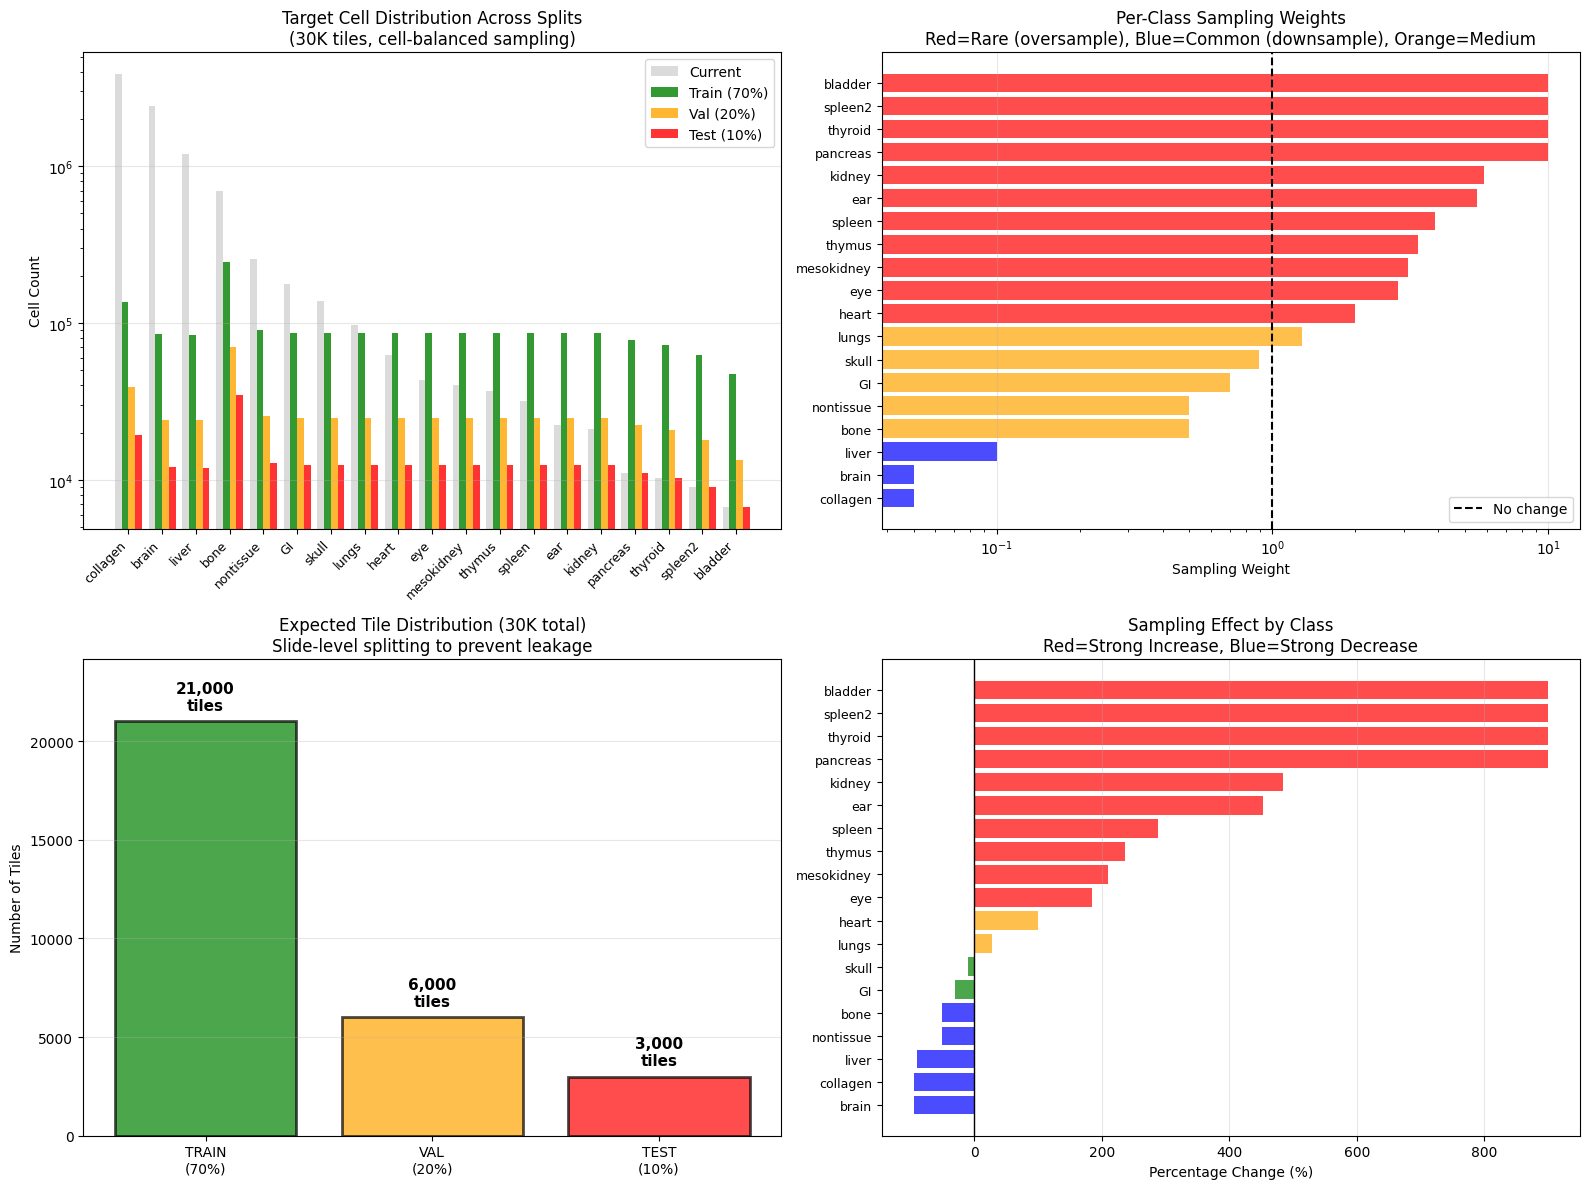


[SAVED] Visualization: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\tile_level_30K_balanced_strategy.png


In [ ]:
# %% SECTION 8: Visualization (UPDATED for 30K tiles)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use 30K target
TARGET_TILES_VIZ = 50000
train_tiles_viz = int(TARGET_TILES_VIZ * PARAMS["train_ratio"])
val_tiles_viz = int(TARGET_TILES_VIZ * PARAMS["val_ratio"])
test_tiles_viz = TARGET_TILES_VIZ - train_tiles_viz - val_tiles_viz

# Panel 1: Current vs Target with splits
ax1 = axes[0, 0]
x = np.arange(len(class_totals))
width = 0.2

# Calculate split targets
train_targets = (hybrid_targets * PARAMS["train_ratio"]).astype(int)
val_targets = (hybrid_targets * PARAMS["val_ratio"]).astype(int)
test_targets = (hybrid_targets * PARAMS["test_ratio"]).astype(int)

ax1.bar(x - 1.5*width, class_totals.values, width, label='Current', alpha=0.8, color='lightgray')
ax1.bar(x - 0.5*width, train_targets.values, width, label='Train (70%)', alpha=0.8, color='green')
ax1.bar(x + 0.5*width, val_targets.values, width, label='Val (20%)', alpha=0.8, color='orange')
ax1.bar(x + 1.5*width, test_targets.values, width, label='Test (10%)', alpha=0.8, color='red')

ax1.set_xticks(x)
ax1.set_xticklabels(class_totals.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Cell Count')
ax1.set_title('Target Cell Distribution Across Splits\n(30K tiles, cell-balanced sampling)')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Sampling weights by category
ax2 = axes[0, 1]

# Color by category
colors_weight = []
for cls in hybrid_weights.index:
    count = class_totals[cls]
    if count < rare_threshold_cells:
        colors_weight.append('red')  # Rare - oversample
    elif count > common_threshold_cells:
        colors_weight.append('blue')  # Common - downsample
    else:
        colors_weight.append('orange')  # Medium

bars = ax2.barh(range(len(hybrid_weights)), hybrid_weights.values, color=colors_weight, alpha=0.7)

ax2.set_yticks(range(len(hybrid_weights)))
ax2.set_yticklabels(hybrid_weights.index, fontsize=9)
ax2.set_xlabel('Sampling Weight')
ax2.set_title('Per-Class Sampling Weights\nRed=Rare (oversample), Blue=Common (downsample), Orange=Medium')
ax2.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='No change')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)
ax2.set_xscale('log')

# Panel 3: Expected tiles per split (30K total)
ax3 = axes[1, 0]
split_names = ['TRAIN\n(70%)', 'VAL\n(20%)', 'TEST\n(10%)']
split_counts = [train_tiles_viz, val_tiles_viz, test_tiles_viz]
colors_split = ['green', 'orange', 'red']

bars = ax3.bar(split_names, split_counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)

for bar, count in zip(bars, split_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + max(split_counts)*0.02,
             f'{count:,}\ntiles',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax3.set_ylabel('Number of Tiles')
ax3.set_title(f'Expected Tile Distribution (30K total)\nSlide-level splitting to prevent leakage')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, max(split_counts) * 1.15)

# Panel 4: Weight effect visualization
ax4 = axes[1, 1]

# Show relative change for each class
changes = ((hybrid_targets - class_totals) / class_totals * 100).sort_values()

colors_change = ['red' if c > 100 else 'orange' if c > 0 else 'green' if c > -50 else 'blue'
                 for c in changes.values]

ax4.barh(range(len(changes)), changes.values, color=colors_change, alpha=0.7)
ax4.set_yticks(range(len(changes)))
ax4.set_yticklabels(changes.index, fontsize=9)
ax4.set_xlabel('Percentage Change (%)')
ax4.set_title('Sampling Effect by Class\nRed=Strong Increase, Blue=Strong Decrease')
ax4.axvline(0, color='black', linestyle='-', linewidth=1)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "tile_level_30K_balanced_strategy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SAVED] Visualization: {OUT_DIR / 'tile_level_30K_balanced_strategy.png'}")

In [36]:
# %% SECTION 9: Summary Report (UPDATED for 30K tiles)
print("\n" + "="*70)
print("TILE-LEVEL CELL-BALANCED STRATEGY - SUMMARY")
print("="*70)

summary_text = f"""
DATASET CONFIGURATION (30K TILES):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Input Data:
  - Total slides: {len(manifest)}
  - Total cells: {class_totals.sum():,}
  - Total classes: {len(class_totals)}

Class Categories:
  - Rare classes: {len(rare_classes)} ({', '.join(rare_classes)})
  - Medium classes: {len(medium_classes)} ({', '.join(medium_classes)})
  - Common classes: {len(common_classes)} ({', '.join(common_classes)})

Sampling Strategy:
  - Target: 30,000 tiles (instead of 168K)
  - Method: Cell-balanced per-class sampling
  - Rare → Oversample to reach target cells
  - Medium → Square root balancing
  - Common → Downsample to 30% of original

Expected Output:
  - Total tiles: ~30,000
  - Train: ~{int(30000 * 0.7):,} tiles (70%)
  - Val: ~{int(30000 * 0.2):,} tiles (20%)
  - Test: ~{int(30000 * 0.1):,} tiles (10%)
  - Target cells: {hybrid_targets.sum():,} ({((hybrid_targets.sum() - class_totals.sum()) / class_totals.sum() * 100):.1f}% change)

Guarantees:
  - All {len(class_totals)} classes in all splits
  - Balanced cell counts per class
  - Slide-level splitting (no data leakage)
  - High-quality tiles prioritized via weighting

Tile Configuration:
  - Tile size: {PARAMS['tile_size']}×{PARAMS['tile_size']} pixels at 20x
  - MPP: {MPP_20X} µm/pixel
  - Physical size: {PARAMS['tile_size']*MPP_20X:.1f}×{PARAMS['tile_size']*MPP_20X:.1f} µm
  - Stride: {PARAMS['stride']} (non-overlapping)
  - Min cells/tile: {PARAMS['min_cells_per_tile']}

Training Efficiency:
  - Iterations/epoch: ~{int(30000 * 0.7) // 32:,}
  - Time/epoch: ~{(int(30000 * 0.7) // 32 * 0.5 / 60):.0f} minutes
  - 50 epochs: ~{(int(30000 * 0.7) // 32 * 0.5 / 3600) * 50:.1f} hours
  
  ✓ 4x faster than 168K tiles!
  ✓ Much faster iteration during development
  ✓ Sufficient data for fine-tuning pretrained CellViT

READY FOR IMPLEMENTATION!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Next Steps:
  1. ✓ Parse GeoJSON annotations (Section 14)
  2. ✓ Generate tile candidates (Section 15)
  3. ▶ Cell-balanced tile selection (Section 16) ← YOU ARE HERE
  4. Assign to train/val/test splits (Section 17)
  5. Extract and save tiles (Section 18-19)
  6. Generate CellViT configs (Section 20)
"""

print(summary_text)
print("="*70)


TILE-LEVEL CELL-BALANCED STRATEGY - SUMMARY

DATASET CONFIGURATION (30K TILES):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Input Data:
  - Total slides: 24
  - Total cells: 9,164,491
  - Total classes: 19

Class Categories:
  - Rare classes: 11 (heart, eye, mesokidney, thymus, spleen, ear, kidney, pancreas, thyroid, spleen2, bladder)
  - Medium classes: 5 (bone, nontissue, GI, skull, lungs)
  - Common classes: 3 (collagen, brain, liver)

Sampling Strategy:
  - Target: 30,000 tiles (instead of 168K)
  - Method: Cell-balanced per-class sampling
  - Rare → Oversample to reach target cells
  - Medium → Square root balancing
  - Common → Downsample to 30% of original

Expected Output:
  - Total tiles: ~30,000
  - Train: ~21,000 tiles (70%)
  - Val: ~6,000 tiles (20%)
  - Test: ~3,000 tiles (10%)
  - Target cells: 2,523,528 (-72.5% change)

Guarantees:
  - All 19 classes in all splits
  - Balanced cell counts per class
  - Slide-level splitting (no data leakage)

In [ ]:
# %% SECTION 11: Configuration for 20x Tile Extraction
import openslide
import cv2
import csv
import shutil
import yaml
from collections import defaultdict, Counter

print("Dependencies loaded")
# Your actual scan parameters
MPP_20X = 0.4416   # Actual MPP at 20x magnification
TILE_SIZE = 256    # Pixels
STRIDE = 256       # Non-overlapping tiles
MIN_CELLS_PER_TILE = 10

# Your class labels (already defined)
LABELS = [
    "bone", "brain", "eye", "heart", "lungs", "GI", "liver", "spleen", 
    "pancreas", "kidney", "mesokidney", "collagen", "ear", "nontissue", 
    "thymus", "thyroid", "bladder", "skull", "spleen2"
]

# Create label mapping
name_to_train = {name: i for i, name in enumerate(LABELS)}
train_to_name = {i: name for i, name in enumerate(LABELS)}

print(f"Working with {len(LABELS)} classes at MPP={MPP_20X}")
print(f"Tile size: {TILE_SIZE}x{TILE_SIZE} pixels = {TILE_SIZE*MPP_20X:.1f}x{TILE_SIZE*MPP_20X:.1f} µm")

print("Additional dependencies loaded for tile extraction")

# %% SECTION 12: Helper Functions for Tile Processing

def get_slide_mpp(slide: openslide.OpenSlide) -> float:
    """Extract MPP from slide, default to 20x if not found."""
    try:
        return float(slide.properties.get(openslide.PROPERTY_NAME_MPP_X, MPP_20X))
    except:
        return MPP_20X

def polygon_centroid(ring: list) -> tuple:
    """Get centroid of polygon."""
    if len(ring) < 3:
        return None, None
    xs, ys = zip(*[(p[0], p[1]) for p in ring])
    return sum(xs)/len(xs), sum(ys)/len(ys)

def assign_cells_to_tiles(cells_xy: np.ndarray, tile_size: int, stride: int) -> dict:
    """
    Assign cells to non-overlapping tile grid.
    
    Returns: {(tile_x, tile_y): [cell_indices]}
    """
    tiles = defaultdict(list)
    
    for idx, (x, y) in enumerate(cells_xy):
        tile_x = int(x // stride) * stride
        tile_y = int(y // stride) * stride
        
        # Check if cell is within tile bounds
        if tile_x <= x < tile_x + tile_size and tile_y <= y < tile_y + tile_size:
            tiles[(tile_x, tile_y)].append(idx)
    
    return tiles

print("Helper functions ready")

def read_ndpi_tile_resampled(
    slide: openslide.OpenSlide,
    x: int,
    y: int,
    tile_size: int,
    source_mpp: float,
    target_mpp: float
) -> np.ndarray:
    """
    Read and resample a tile from NDPI to target MPP.
    
    Args:
        slide: OpenSlide object
        x, y: Top-left coordinates at target resolution
        tile_size: Output tile size
        source_mpp: Source microns per pixel
        target_mpp: Target microns per pixel
    
    Returns:
        RGB numpy array of shape (tile_size, tile_size, 3)
    """
    scale = source_mpp / target_mpp
    
    # Calculate source coordinates and size
    x_src = int(x / scale)
    y_src = int(y / scale)
    size_src = int(np.ceil(tile_size / scale))
    
    # Read at level 0 (highest resolution)
    try:
        tile_pil = slide.read_region((x_src, y_src), 0, (size_src, size_src))
        tile_rgb = np.array(tile_pil.convert('RGB'))
        
        # Resize to target size if needed
        if tile_rgb.shape[0] != tile_size or tile_rgb.shape[1] != tile_size:
            tile_rgb = cv2.resize(tile_rgb, (tile_size, tile_size), interpolation=cv2.INTER_LINEAR)
        
        return tile_rgb
    except Exception as e:
        print(f"  Warning: Failed to read tile at ({x_src}, {y_src}): {e}")
        return np.zeros((tile_size, tile_size, 3), dtype=np.uint8)

print("Helper functions defined")

# %% SECTION 13: TileInfo Data Structure

@dataclass
class TileInfo:
    """Information about a candidate tile for extraction."""
    slide_id: str
    tile_idx: int
    grid_x: int
    grid_y: int
    x_coord: int
    y_coord: int
    cell_indices: List[int]
    class_counts: Counter = field(default_factory=Counter)
    assigned_split: str = None
    priority_score: float = 0.0
    
    @property
    def tile_id(self) -> str:
        """Generate unique tile identifier."""
        return f"{self.slide_id}_t{self.tile_idx}_{self.x_coord}_{self.y_coord}"
    
    @property
    def num_cells(self) -> int:
        """Total cells in this tile."""
        return len(self.cell_indices)
    
    def update_class_counts(self, labels: np.ndarray):
        """Update class counts from label array."""
        self.class_counts = Counter(labels[self.cell_indices].tolist())
    
    def calculate_priority(self, rare_classes: Set[int], target_weights: Dict[int, float]):
        """
        Calculate priority score for tile selection.
        Higher score = higher priority for inclusion.
        
        Priority based on:
        1. Presence of rare classes
        2. Class diversity
        3. Target sampling weights
        """
        score = 0.0
        
        # Bonus for rare classes
        rare_count = sum(self.class_counts[c] for c in rare_classes if c in self.class_counts)
        score += rare_count * 10.0
        
        # Bonus for diversity (number of unique classes)
        score += len(self.class_counts) * 2.0
        
        # Weighted by target sampling needs
        for cls, count in self.class_counts.items():
            weight = target_weights.get(cls, 1.0)
            score += count * weight
        
        self.priority_score = score
        return score

print("TileInfo dataclass defined")

Dependencies loaded
Working with 19 classes at MPP=0.4416
Tile size: 256x256 pixels = 113.0x113.0 µm
Additional dependencies loaded for tile extraction
Helper functions ready
Helper functions defined
TileInfo dataclass defined


In [27]:
# %% SECTION 14: Parse All GeoJSON Files and Collect Cell Information

print("\n" + "="*70)
print("PARSING GEOJSON ANNOTATIONS")
print("="*70)

# Load manifest
manifest = json.loads(MANIFEST_JSON.read_text(encoding="utf-8"))

# Store slide-level information
slide_data = {}

for entry in tqdm(manifest, desc="Parsing GeoJSON files"):
    slide_id = entry["slide_id"]
    geojson_path = Path(entry["geojson_path"])
    
    if not geojson_path.exists():
        print(f"  WARNING: Missing {geojson_path.name}")
        continue
    
    # Parse GeoJSON
    gj_raw = json.loads(geojson_path.read_text(encoding="utf-8"))
    
    # Handle both formats: {"features": [...]} or just [...]
    if isinstance(gj_raw, dict):
        features = gj_raw.get("features", [])
    elif isinstance(gj_raw, list):
        features = gj_raw
    else:
        print(f"  WARNING: Unexpected GeoJSON format for {slide_id}")
        continue
    
    centroids = []
    labels = []
    
    for feat in features:
        # Get class
        props = feat.get("properties", {})
        
        # Try different property paths (QuPath vs custom format)
        class_name = None
        if "classification" in props:
            class_name = props["classification"].get("name")
        elif "class" in props:
            class_name = props["class"]
        elif "name" in props:
            class_name = props["name"]
        
        if not class_name or class_name not in name_to_train:
            continue
        
        # Get centroid
        geom = feat.get("geometry", {})
        if geom.get("type") != "Polygon":
            continue
        
        coords = geom.get("coordinates", [[]])
        if not coords or len(coords) == 0:
            continue
            
        cx, cy = polygon_centroid(coords[0])
        if cx is None:
            continue
        
        centroids.append([cx, cy])
        labels.append(name_to_train[class_name])
    
    if centroids:
        slide_data[slide_id] = {
            "image_path": entry["image_path"],
            "geojson_path": str(geojson_path),
            "cells_xy": np.array(centroids, dtype=np.float32),
            "cells_labels": np.array(labels, dtype=np.int32),
            "num_cells": len(centroids)
        }

print(f"\n[SUMMARY] Parsed {len(slide_data)} slides with annotations")
total_cells_parsed = sum(data['num_cells'] for data in slide_data.values())
print(f"Total cells parsed: {total_cells_parsed:,}")

# Show first few slides
print("\nFirst few slides:")
for sid, data in list(slide_data.items())[:5]:
    print(f"  {sid}: {data['num_cells']:,} cells")


PARSING GEOJSON ANNOTATIONS


Parsing GeoJSON files:   0%|          | 0/24 [00:00<?, ?it/s]


[SUMMARY] Parsed 23 slides with annotations
Total cells parsed: 9,164,491

First few slides:
  monkey_fetus_40_0001: 11,650 cells
  monkey_fetus_40_0051: 97,541 cells
  monkey_fetus_40_0101: 177,587 cells
  monkey_fetus_40_0151: 145,536 cells
  monkey_fetus_40_0201: 355,703 cells


In [37]:
# %% SECTION 15: Generate Tile Candidates with Class-Based Sampling

print("\n" + "="*70)
print("GENERATING WEIGHTED TILE CANDIDATES")
print("="*70)

# Identify rare classes for prioritization
rare_class_ids = set(name_to_train[c] for c in LABELS 
                     if c in class_totals.index and (class_totals[c] / total_cells) < 0.01)

print(f"Rare classes (prioritized): {[train_to_name[i] for i in rare_class_ids]}")

# Generate tile candidates for each slide
all_tile_info = []

for slide_id, data in tqdm(slide_data.items(), desc="Generating tiles"):
    cells_xy = data["cells_xy"]
    cells_labels = data["cells_labels"]
    
    # Assign cells to tiles
    tile_groups = assign_cells_to_tiles(cells_xy, TILE_SIZE, STRIDE)
    
    # Filter by minimum cell count and create tile records
    for (tx, ty), cell_indices in tile_groups.items():
        if len(cell_indices) < MIN_CELLS_PER_TILE:
            continue
        
        # Count classes in this tile
        tile_labels = cells_labels[cell_indices]
        class_counts = Counter(tile_labels.tolist())
        
        # Calculate tile weight based on our hybrid sampling strategy
        tile_weight = 0.0
        for cls_id, count in class_counts.items():
            cls_name = train_to_name[cls_id]
            if cls_name in hybrid_weights.index:
                tile_weight += count * hybrid_weights[cls_name]
        
        tile_weight /= len(cell_indices)  # Normalize by tile cell count
        
        # Bonus for rare classes
        if any(cls_id in rare_class_ids for cls_id in class_counts):
            tile_weight *= 2.0
        
        all_tile_info.append({
            "slide_id": slide_id,
            "tile_x": tx,
            "tile_y": ty,
            "cell_indices": cell_indices,
            "num_cells": len(cell_indices),
            "class_counts": class_counts,
            "weight": tile_weight
        })

print(f"\n[SUMMARY] Generated {len(all_tile_info):,} candidate tiles")
print(f"  Min cells/tile: {min(t['num_cells'] for t in all_tile_info)}")
print(f"  Max cells/tile: {max(t['num_cells'] for t in all_tile_info)}")
print(f"  Avg cells/tile: {np.mean([t['num_cells'] for t in all_tile_info]):.1f}")


GENERATING WEIGHTED TILE CANDIDATES
Rare classes (prioritized): ['eye', 'heart', 'spleen', 'pancreas', 'kidney', 'mesokidney', 'ear', 'thymus', 'thyroid', 'bladder', 'spleen2']


Generating tiles:   0%|          | 0/23 [00:00<?, ?it/s]


[SUMMARY] Generated 116,172 candidate tiles
  Min cells/tile: 5
  Max cells/tile: 509
  Avg cells/tile: 78.6



RARE CLASS OVERSAMPLING STRATEGY

Class categorization:
Class              Tiles % of Dataset Category
------------------------------------------------------------
bone              11,192        9.63% 🔴 BIG4
brain             21,988       18.93% 🔴 BIG4
eye                  495        0.43% 🟢 RARE
heart              1,442        1.24% 🟡 COMMON
lungs                947        0.82% 🟡 COMMON
GI                 3,702        3.19% 🟡 COMMON
liver              8,821        7.59% 🔴 BIG4
spleen               411        0.35% 🟢 RARE
pancreas             113        0.10% 🟢 RARE
kidney               223        0.19% 🟢 RARE
mesokidney           591        0.51% 🟡 COMMON
collagen          84,093       72.39% 🔴 BIG4
ear                  497        0.43% 🟢 RARE
nontissue         53,622       46.16% 🟡 COMMON
thymus               617        0.53% 🟡 COMMON
thyroid              230        0.20% 🟢 RARE
bladder              926        0.80% 🟡 COMMON
skull              9,139        7.87% 🟡 COMMON
spleen2  

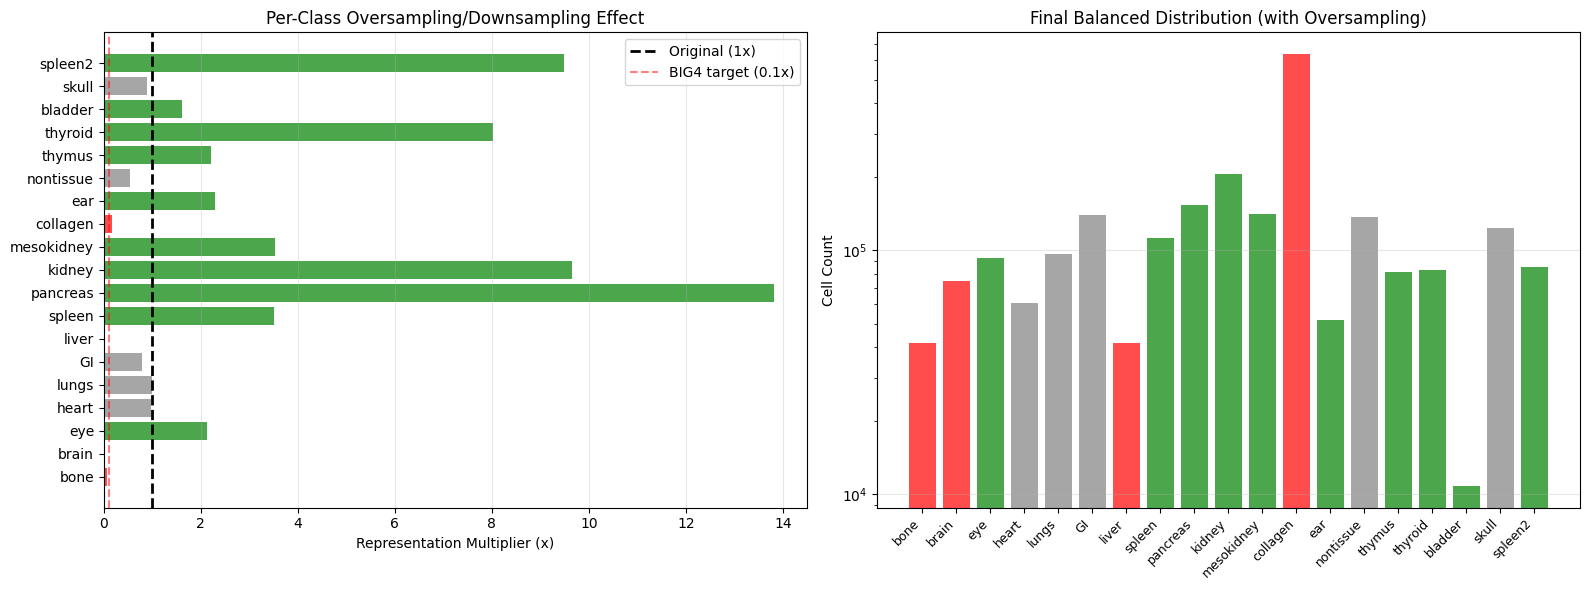


[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\rare_class_oversampling.png


In [50]:
# %% SECTION 16: Rare Class Oversampling (v5)

print("\n" + "="*70)
print("RARE CLASS OVERSAMPLING STRATEGY")
print("="*70)

TARGET_TOTAL_TILES = 30000

# Define the BIG4 and categorize classes
BIG_4_NAMES = ['collagen', 'bone', 'brain', 'liver']
BIG_4_IDS = {name_to_train[name] for name in BIG_4_NAMES}

# Identify tiles by class
tiles_by_primary_class = defaultdict(list)
tiles_by_any_class = defaultdict(list)

for idx, tile in enumerate(all_tile_info):
    if tile["class_counts"]:
        primary_class = max(tile["class_counts"].items(), key=lambda x: x[1])[0]
        tiles_by_primary_class[primary_class].append(idx)
        
        for cls_id in tile["class_counts"].keys():
            tiles_by_any_class[cls_id].append(idx)

# Categorize classes
RARE_THRESHOLD = 500
rare_class_ids = set()

print(f"\nClass categorization:")
print(f"{'Class':<15} {'Tiles':>8} {'% of Dataset':>12} {'Category'}")
print("-" * 60)

for cls_name in LABELS:
    cls_id = name_to_train[cls_name]
    n_tiles = len(tiles_by_any_class.get(cls_id, []))
    pct_dataset = (n_tiles / len(all_tile_info)) * 100
    
    if cls_id in BIG_4_IDS:
        category = "🔴 BIG4"
    elif n_tiles < RARE_THRESHOLD:
        category = "🟢 RARE"
        rare_class_ids.add(cls_id)
    else:
        category = "🟡 COMMON"
    
    print(f"{cls_name:<15} {n_tiles:>8,} {pct_dataset:>11.2f}% {category}")

# STAGE 1: Include ALL rare class tiles AND oversample them
print("\n" + "="*70)
print("STAGE 1: RARE CLASS INCLUSION + OVERSAMPLING")
print("="*70)

# Define oversampling targets
OVERSAMPLE_TARGETS = {
    'kidney': 2000,      # From 223 → 2000 tiles (9x)
    'pancreas': 1500,    # From 113 → 1500 tiles (13x)
    'spleen': 1200,      # From 411 → 1200 tiles (3x)
    'spleen2': 1000,     # From 119 → 1000 tiles (8x)
    'thyroid': 1500,     # From 230 → 1500 tiles (7x)
    'bladder': 1500,     # From 926 → 1500 tiles (1.6x)
    'ear': 1200,         # From 497 → 1200 tiles (2.4x)
    'eye': 1000,         # From 495 → 1000 tiles (2x)
    'mesokidney': 1200,  # From 591 → 1200 tiles (2x)
    'thymus': 1200,      # From 617 → 1200 tiles (2x)
}

stage1_indices = []
oversample_counts = Counter()

np.random.seed(PARAMS["seed"])

for cls_name, target_tiles in OVERSAMPLE_TARGETS.items():
    cls_id = name_to_train[cls_name]
    available_tiles = tiles_by_any_class.get(cls_id, [])
    
    if len(available_tiles) == 0:
        print(f"  ⚠️  {cls_name}: No tiles available!")
        continue
    
    # Include all original tiles first
    stage1_indices.extend(available_tiles)
    original_count = len(available_tiles)
    
    # Oversample with replacement to reach target
    if len(available_tiles) < target_tiles:
        n_oversample = target_tiles - len(available_tiles)
        oversampled = np.random.choice(available_tiles, size=n_oversample, replace=True)
        stage1_indices.extend(oversampled.tolist())
        oversample_counts[cls_name] = n_oversample
        
        print(f"  {cls_name:12s}: {original_count:>4} original → {target_tiles:>4} total (+{n_oversample:>4} oversampled, {target_tiles/original_count:.1f}x)")
    else:
        print(f"  {cls_name:12s}: {original_count:>4} tiles (no oversampling needed)")

# Remove duplicates for count
stage1_unique = len(set(stage1_indices))
stage1_total = len(stage1_indices)

print(f"\nStage 1 summary:")
print(f"  Unique tiles: {stage1_unique:,}")
print(f"  Total tiles (with oversampling): {stage1_total:,}")
print(f"  Oversampling factor: {stage1_total/stage1_unique:.2f}x")

# Calculate cell counts from stage 1
stage1_class_counts = Counter()
for idx in stage1_indices:
    stage1_class_counts.update(all_tile_info[idx]["class_counts"])

print(f"\nStage 1 cell representation:")
for cls_name in sorted(OVERSAMPLE_TARGETS.keys()):
    cls_id = name_to_train[cls_name]
    count = stage1_class_counts.get(cls_id, 0)
    original = class_totals[cls_name]
    multiplier = count / original if original > 0 else 0
    print(f"  {cls_name:12s}: {count:>8,} cells ({multiplier:.1f}x of original {original:,})")

# STAGE 2: Sample remaining tiles, aggressively penalize BIG4
print("\n" + "="*70)
print("STAGE 2: BALANCE REMAINING CLASSES (PENALIZE BIG4)")
print("="*70)

remaining_slots = TARGET_TOTAL_TILES - stage1_total
print(f"Remaining slots: {remaining_slots:,}")

if remaining_slots > 0:
    # Get tiles NOT in stage 1 (unique tiles only)
    stage1_set = set(stage1_indices)
    remaining_indices = [i for i in range(len(all_tile_info)) if i not in stage1_set]
    
    print(f"Available tiles: {len(remaining_indices):,}")
    
    # Calculate weights with BIG4 penalty
    tile_weights = []
    
    for idx in remaining_indices:
        tile = all_tile_info[idx]
        total_cells = sum(tile["class_counts"].values())
        
        value = 0.0
        for cls_id, count in tile["class_counts"].items():
            if cls_id in BIG_4_IDS:
                value += count * 0.03  # 97% penalty!
            elif cls_id in rare_class_ids:
                value += count * 5.0   # 5x boost (shouldn't happen, already in stage1)
            else:
                value += count * 1.0
        
        value /= total_cells
        
        # Additional penalty if BIG4 dominates
        big4_cells = sum(tile["class_counts"].get(big4_id, 0) for big4_id in BIG_4_IDS)
        if big4_cells / total_cells > 0.5:
            value *= 0.05  # 95% additional penalty
        
        tile_weights.append(value)
    
    tile_weights = np.array(tile_weights)
    tile_weights = np.maximum(tile_weights, 1e-8)
    
    # Sample
    n_sample = min(remaining_slots, len(remaining_indices))
    tile_probs = tile_weights / tile_weights.sum()
    
    stage2_indices = np.random.choice(
        remaining_indices,
        size=n_sample,
        replace=False,
        p=tile_probs
    )
    
    print(f"Sampled {len(stage2_indices):,} additional tiles")
else:
    stage2_indices = []
    print("⚠️  Stage 1 already exceeded target! Using only stage 1 tiles.")
    stage1_indices = stage1_indices[:TARGET_TOTAL_TILES]

# Combine stages (stage1 has duplicates, stage2 doesn't)
all_selected_indices = stage1_indices + list(stage2_indices)
selected_tiles = [all_tile_info[i] for i in all_selected_indices]

print(f"\n[DONE] Total: {len(selected_tiles):,} tiles")

# Verify distribution
sampled_class_counts = Counter()
tiles_per_class = Counter()

for tile in selected_tiles:
    sampled_class_counts.update(tile["class_counts"])
    for cls_id in tile["class_counts"].keys():
        tiles_per_class[cls_id] += 1

print("\n" + "="*70)
print("FINAL RESULTS WITH RARE CLASS OVERSAMPLING")
print("="*70)
print(f"{'Class':<15} {'Original':>10} {'Sampled':>10} {'Multiplier':>11} {'Tiles':>8} {'Status'}")
print("-" * 80)

for cls_name in LABELS:
    cls_id = name_to_train[cls_name]
    original = class_totals[cls_name]
    sampled = sampled_class_counts.get(cls_id, 0)
    multiplier = sampled / original if original > 0 else 0
    n_tiles = tiles_per_class.get(cls_id, 0)
    
    if cls_name in OVERSAMPLE_TARGETS:
        if multiplier >= 5:
            status = "🟢 BOOSTED 5x+"
        elif multiplier >= 2:
            status = "🟢 BOOSTED 2x+"
        else:
            status = "🟢 BOOSTED"
    elif cls_id in BIG_4_IDS:
        if multiplier < 0.1:
            status = "🔴 REDUCED ✓"
        else:
            status = "🔴 REDUCED"
    else:
        status = "🟡 NORMAL"
    
    print(f"{cls_name:<15} {original:>10,} {sampled:>10,} {multiplier:>10.2f}x {n_tiles:>8,} {status}")

# Balance metrics
actual_counts = [sampled_class_counts.get(name_to_train[c], 1) for c in LABELS]
balance_ratio = max(actual_counts) / min(actual_counts)

print("\n" + "="*70)
print("BALANCE QUALITY WITH OVERSAMPLING")
print("="*70)

print(f"""
Total tiles: {len(selected_tiles):,}
Total cells: {sum(sampled_class_counts.values()):,}
Unique tiles: {len(set(all_selected_indices)):,}
Oversampling factor: {len(all_selected_indices) / len(set(all_selected_indices)):.2f}x

🟢 RARE class representation (after oversampling):
  kidney:    {sampled_class_counts.get(name_to_train['kidney'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['kidney'], 0)/class_totals['kidney']:.1f}x original)
  pancreas:  {sampled_class_counts.get(name_to_train['pancreas'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['pancreas'], 0)/class_totals['pancreas']:.1f}x original)
  spleen:    {sampled_class_counts.get(name_to_train['spleen'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['spleen'], 0)/class_totals['spleen']:.1f}x original)
  thyroid:   {sampled_class_counts.get(name_to_train['thyroid'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['thyroid'], 0)/class_totals['thyroid']:.1f}x original)
  bladder:   {sampled_class_counts.get(name_to_train['bladder'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['bladder'], 0)/class_totals['bladder']:.1f}x original)

🔴 BIG4 downsampling:
  collagen:  {sampled_class_counts.get(name_to_train['collagen'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['collagen'], 0)/class_totals['collagen']*100:.1f}%)
  bone:      {sampled_class_counts.get(name_to_train['bone'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['bone'], 0)/class_totals['bone']*100:.1f}%)
  brain:     {sampled_class_counts.get(name_to_train['brain'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['brain'], 0)/class_totals['brain']*100:.1f}%)
  liver:     {sampled_class_counts.get(name_to_train['liver'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['liver'], 0)/class_totals['liver']*100:.1f}%)

Max/Min ratio: {balance_ratio:.1f}x {'✓ Excellent' if balance_ratio < 50 else '✓ Good' if balance_ratio < 100 else '~ Acceptable'}

⚠️  NOTE: Rare classes are oversampled (tiles duplicated). This is intentional to:
   1. Increase their representation during training
   2. Prevent model from ignoring rare classes
   3. Balance learning signal across all classes
   
   During training, the model will see these tiles multiple times per epoch,
   effectively giving rare classes more weight.
""")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Multiplier effect
ax1 = axes[0]
multipliers = []
colors = []

for cls_name in LABELS:
    cls_id = name_to_train[cls_name]
    original = class_totals[cls_name]
    sampled = sampled_class_counts.get(cls_id, 0)
    mult = sampled / original if original > 0 else 0
    multipliers.append(mult)
    
    if cls_name in OVERSAMPLE_TARGETS:
        colors.append('green')
    elif cls_id in BIG_4_IDS:
        colors.append('red')
    else:
        colors.append('gray')

ax1.barh(LABELS, multipliers, color=colors, alpha=0.7)
ax1.set_xlabel('Representation Multiplier (x)')
ax1.set_title('Per-Class Oversampling/Downsampling Effect')
ax1.axvline(1.0, color='black', linestyle='--', linewidth=2, label='Original (1x)')
ax1.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='BIG4 target (0.1x)')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Panel 2: Final distribution
ax2 = axes[1]
final_counts = [sampled_class_counts.get(name_to_train[c], 1) for c in LABELS]

ax2.bar(LABELS, final_counts, color=colors, alpha=0.7)
ax2.set_xticks(range(len(LABELS)))
ax2.set_xticklabels(LABELS, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Cell Count')
ax2.set_title('Final Balanced Distribution (with Oversampling)')
ax2.set_yscale('log')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "rare_class_oversampling.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SAVED] {OUT_DIR / 'rare_class_oversampling.png'}")


FINE-TUNED RARE CLASS OVERSAMPLING

🎯 Target: Aggressively downsample ['collagen', 'bone', 'brain', 'liver', 'nontissue']

Class categorization:
Class              Tiles   % Dataset Category
------------------------------------------------------------
bone              11,192       9.63% 🔴 BIG5
brain             21,988      18.93% 🔴 BIG5
eye                  495       0.43% 🟢 RARE
heart              1,442       1.24% 🟡 COMMON
lungs                947       0.82% 🟡 COMMON
GI                 3,702       3.19% 🟡 COMMON
liver              8,821       7.59% 🔴 BIG5
spleen               411       0.35% 🟢 RARE
pancreas             113       0.10% 🟢 RARE
kidney               223       0.19% 🟢 RARE
mesokidney           591       0.51% 🟡 COMMON
collagen          84,093      72.39% 🔴 BIG5
ear                  497       0.43% 🟢 RARE
nontissue         53,622      46.16% 🔴 BIG5
thymus               617       0.53% 🟡 COMMON
thyroid              230       0.20% 🟢 RARE
bladder              926       0.

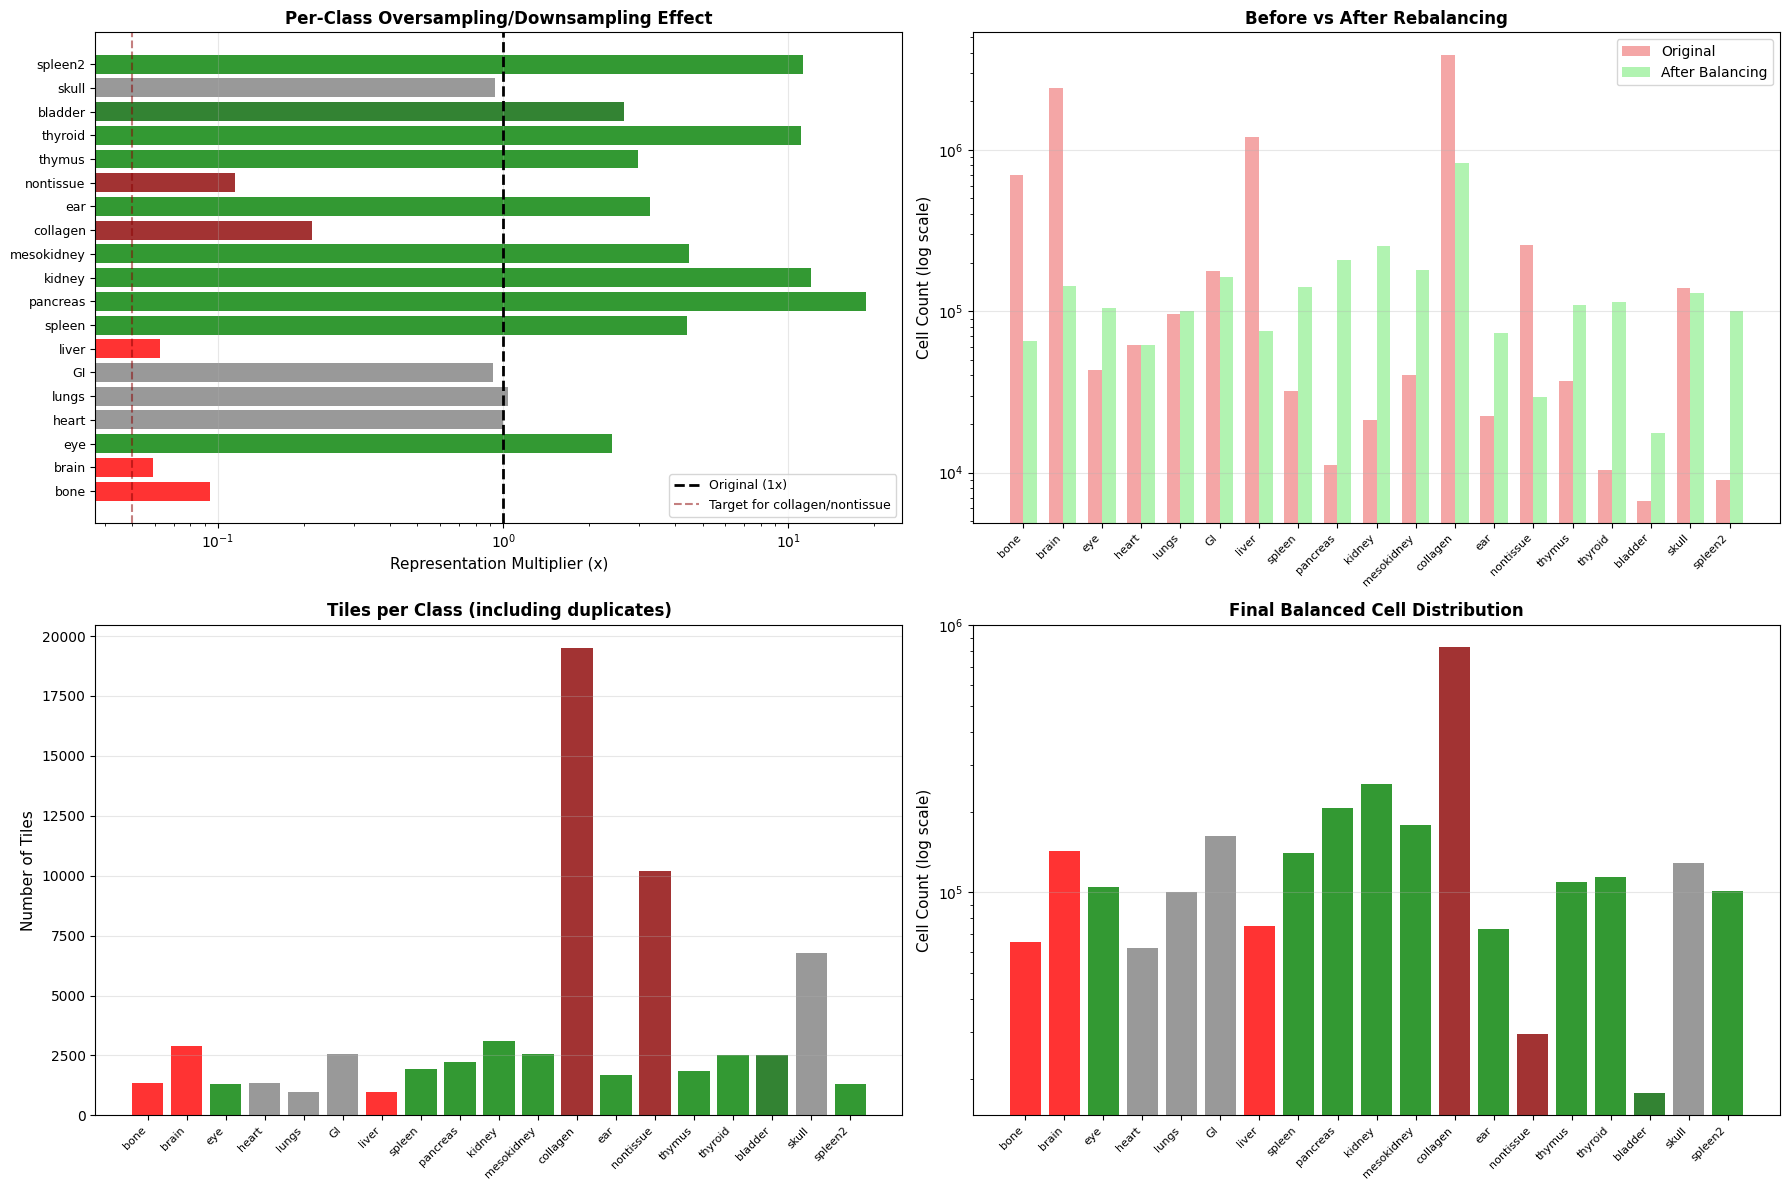


[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\fine_tuned_oversampling.png


In [52]:
# %% SECTION 16: Fine-Tuned Rare Class Oversampling (v6)

print("\n" + "="*70)
print("FINE-TUNED RARE CLASS OVERSAMPLING")
print("="*70)

TARGET_TOTAL_TILES = 30000

# Expand BIG4 to BIG5 (add nontissue)
BIG_5_NAMES = ['collagen', 'bone', 'brain', 'liver', 'nontissue']
BIG_5_IDS = {name_to_train[name] for name in BIG_5_NAMES}

print(f"\n🎯 Target: Aggressively downsample {BIG_5_NAMES}")

# Identify tiles by class
tiles_by_primary_class = defaultdict(list)
tiles_by_any_class = defaultdict(list)

for idx, tile in enumerate(all_tile_info):
    if tile["class_counts"]:
        primary_class = max(tile["class_counts"].items(), key=lambda x: x[1])[0]
        tiles_by_primary_class[primary_class].append(idx)
        
        for cls_id in tile["class_counts"].keys():
            tiles_by_any_class[cls_id].append(idx)

# Categorize classes
RARE_THRESHOLD = 500
rare_class_ids = set()

print(f"\nClass categorization:")
print(f"{'Class':<15} {'Tiles':>8} {'% Dataset':>11} {'Category'}")
print("-" * 60)

for cls_name in LABELS:
    cls_id = name_to_train[cls_name]
    n_tiles = len(tiles_by_any_class.get(cls_id, []))
    pct_dataset = (n_tiles / len(all_tile_info)) * 100
    
    if cls_id in BIG_5_IDS:
        category = "🔴 BIG5"
    elif n_tiles < RARE_THRESHOLD:
        category = "🟢 RARE"
        rare_class_ids.add(cls_id)
    else:
        category = "🟡 COMMON"
    
    print(f"{cls_name:<15} {n_tiles:>8,} {pct_dataset:>10.2f}% {category}")

# STAGE 1: Rare class oversampling
print("\n" + "="*70)
print("STAGE 1: RARE CLASS OVERSAMPLING")
print("="*70)

# Updated oversampling targets - INCREASED bladder significantly
OVERSAMPLE_TARGETS = {
    'kidney': 2500,      # From 223 → 2500 tiles (11x) - increased
    'pancreas': 2000,    # From 113 → 2000 tiles (18x) - increased
    'bladder': 2500,     # From 926 → 2500 tiles (2.7x) - ⭐ INCREASED
    'spleen': 1500,      # From 411 → 1500 tiles (3.6x) - increased
    'spleen2': 1200,     # From 119 → 1200 tiles (10x)
    'thyroid': 2000,     # From 230 → 2000 tiles (8.7x) - increased
    'ear': 1500,         # From 497 → 1500 tiles (3x)
    'eye': 1200,         # From 495 → 1200 tiles (2.4x)
    'mesokidney': 1500,  # From 591 → 1500 tiles (2.5x)
    'thymus': 1500,      # From 617 → 1500 tiles (2.4x)
}

stage1_indices = []
oversample_counts = Counter()

np.random.seed(PARAMS["seed"])

print(f"{'Class':<13} {'Original':>9} {'Target':>8} {'Multiplier':>11} {'Added':>8}")
print("-" * 60)

for cls_name, target_tiles in OVERSAMPLE_TARGETS.items():
    cls_id = name_to_train[cls_name]
    available_tiles = tiles_by_any_class.get(cls_id, [])
    
    if len(available_tiles) == 0:
        print(f"  ⚠️  {cls_name}: No tiles available!")
        continue
    
    # Include all original tiles
    stage1_indices.extend(available_tiles)
    original_count = len(available_tiles)
    
    # Oversample to reach target
    if len(available_tiles) < target_tiles:
        n_oversample = target_tiles - len(available_tiles)
        oversampled = np.random.choice(available_tiles, size=n_oversample, replace=True)
        stage1_indices.extend(oversampled.tolist())
        oversample_counts[cls_name] = n_oversample
        multiplier = target_tiles / original_count
        
        # Highlight bladder
        highlight = "⭐" if cls_name == 'bladder' else "  "
        print(f"{highlight}{cls_name:11s} {original_count:>9,} {target_tiles:>8,} {multiplier:>10.1f}x +{n_oversample:>7,}")
    else:
        print(f"  {cls_name:11s} {original_count:>9,} (no oversampling needed)")

stage1_unique = len(set(stage1_indices))
stage1_total = len(stage1_indices)

print(f"\n📊 Stage 1 summary:")
print(f"  Unique tiles: {stage1_unique:,}")
print(f"  Total tiles (with oversampling): {stage1_total:,}")
print(f"  Oversampling factor: {stage1_total/stage1_unique:.2f}x")

# Cell counts from stage 1
stage1_class_counts = Counter()
for idx in stage1_indices:
    stage1_class_counts.update(all_tile_info[idx]["class_counts"])

print(f"\n🟢 Rare class cell representation (after oversampling):")
print(f"{'Class':<13} {'Original':>10} {'After OS':>10} {'Multiplier':>11}")
print("-" * 50)

for cls_name in sorted(OVERSAMPLE_TARGETS.keys()):
    cls_id = name_to_train[cls_name]
    original = class_totals[cls_name]
    after_os = stage1_class_counts.get(cls_id, 0)
    multiplier = after_os / original if original > 0 else 0
    
    highlight = "⭐" if cls_name == 'bladder' else "  "
    print(f"{highlight}{cls_name:11s} {original:>10,} {after_os:>10,} {multiplier:>10.1f}x")

# STAGE 2: Sample remaining, heavily penalize BIG5
print("\n" + "="*70)
print("STAGE 2: BALANCE REMAINING CLASSES (ULTRA-PENALIZE BIG5)")
print("="*70)

remaining_slots = TARGET_TOTAL_TILES - stage1_total
print(f"Remaining slots: {remaining_slots:,}")

if remaining_slots > 0:
    stage1_set = set(stage1_indices)
    remaining_indices = [i for i in range(len(all_tile_info)) if i not in stage1_set]
    
    print(f"Available tiles: {len(remaining_indices):,}")
    
    # Calculate weights with ULTRA-HEAVY BIG5 penalty
    tile_weights = []
    
    for idx in remaining_indices:
        tile = all_tile_info[idx]
        total_cells = sum(tile["class_counts"].values())
        
        value = 0.0
        for cls_id, count in tile["class_counts"].items():
            if cls_id in BIG_5_IDS:
                # Ultra-aggressive penalty
                if train_to_name[cls_id] == 'collagen':
                    value += count * 0.01  # 99% penalty for collagen!
                elif train_to_name[cls_id] == 'nontissue':
                    value += count * 0.02  # 98% penalty for nontissue!
                else:
                    value += count * 0.03  # 97% penalty for others
            elif cls_id in rare_class_ids:
                value += count * 5.0  # Shouldn't happen, but boost if present
            else:
                value += count * 1.0
        
        value /= total_cells
        
        # Additional mega-penalty if BIG5 dominates
        big5_cells = sum(tile["class_counts"].get(big5_id, 0) for big5_id in BIG_5_IDS)
        if big5_cells / total_cells > 0.6:
            value *= 0.01  # 99% additional penalty!
        elif big5_cells / total_cells > 0.4:
            value *= 0.05  # 95% additional penalty
        
        tile_weights.append(value)
    
    tile_weights = np.array(tile_weights)
    tile_weights = np.maximum(tile_weights, 1e-10)
    
    print(f"\nTile weight distribution:")
    print(f"  Min:    {tile_weights.min():.8f}")
    print(f"  Median: {np.median(tile_weights):.8f}")
    print(f"  Mean:   {tile_weights.mean():.8f}")
    print(f"  Max:    {tile_weights.max():.8f}")
    
    # Sample
    n_sample = min(remaining_slots, len(remaining_indices))
    tile_probs = tile_weights / tile_weights.sum()
    
    stage2_indices = np.random.choice(
        remaining_indices,
        size=n_sample,
        replace=False,
        p=tile_probs
    )
    
    print(f"Sampled {len(stage2_indices):,} additional tiles")
else:
    stage2_indices = []
    print("⚠️  Stage 1 already exceeded target!")
    stage1_indices = stage1_indices[:TARGET_TOTAL_TILES]

# Combine stages
all_selected_indices = stage1_indices + list(stage2_indices)
selected_tiles = [all_tile_info[i] for i in all_selected_indices]

print(f"\n[DONE] Total: {len(selected_tiles):,} tiles")

# Verify distribution
sampled_class_counts = Counter()
tiles_per_class = Counter()

for tile in selected_tiles:
    sampled_class_counts.update(tile["class_counts"])
    for cls_id in tile["class_counts"].keys():
        tiles_per_class[cls_id] += 1

print("\n" + "="*70)
print("FINAL FINE-TUNED RESULTS")
print("="*70)
print(f"{'Class':<15} {'Original':>10} {'Sampled':>10} {'Multiplier':>11} {'Tiles':>8} {'Status'}")
print("-" * 85)

for cls_name in LABELS:
    cls_id = name_to_train[cls_name]
    original = class_totals[cls_name]
    sampled = sampled_class_counts.get(cls_id, 0)
    multiplier = sampled / original if original > 0 else 0
    n_tiles = tiles_per_class.get(cls_id, 0)
    
    if cls_name in OVERSAMPLE_TARGETS:
        if multiplier >= 10:
            status = "🟢 MEGA BOOST"
        elif multiplier >= 5:
            status = "🟢 BIG BOOST"
        elif multiplier >= 2:
            status = "🟢 BOOSTED"
        else:
            status = "🟢 RARE"
    elif cls_id in BIG_5_IDS:
        if multiplier < 0.05:
            status = "🔴 CRUSHED ✓✓"
        elif multiplier < 0.1:
            status = "🔴 REDUCED ✓"
        else:
            status = "🔴 REDUCED"
    else:
        status = "🟡 NORMAL"
    
    # Highlight key classes
    highlight = ""
    if cls_name == 'bladder':
        highlight = "⭐"
    elif cls_name == 'collagen':
        highlight = "🎯"
    elif cls_name == 'nontissue':
        highlight = "🎯"
    
    print(f"{highlight}{cls_name:<14} {original:>10,} {sampled:>10,} {multiplier:>10.2f}x {n_tiles:>8,} {status}")

# Balance metrics
actual_counts = [sampled_class_counts.get(name_to_train[c], 1) for c in LABELS]
balance_ratio = max(actual_counts) / min(actual_counts)

print("\n" + "="*70)
print("BALANCE QUALITY REPORT")
print("="*70)

print(f"""
Total tiles: {len(selected_tiles):,}
Total cells: {sum(sampled_class_counts.values()):,}
Unique tiles: {len(set(all_selected_indices)):,}
Oversampling factor: {len(all_selected_indices) / len(set(all_selected_indices)):.2f}x

⭐ KEY IMPROVEMENTS:
  bladder:   {class_totals['bladder']:>6,} → {sampled_class_counts.get(name_to_train['bladder'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['bladder'], 0)/class_totals['bladder']:.1f}x) ← INCREASED!
  kidney:    {class_totals['kidney']:>6,} → {sampled_class_counts.get(name_to_train['kidney'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['kidney'], 0)/class_totals['kidney']:.1f}x)
  pancreas:  {class_totals['pancreas']:>6,} → {sampled_class_counts.get(name_to_train['pancreas'], 0):>8,} cells ({sampled_class_counts.get(name_to_train['pancreas'], 0)/class_totals['pancreas']:.1f}x)

🎯 BIG5 DOWNSAMPLING:
  collagen:  {class_totals['collagen']:>7,} → {sampled_class_counts.get(name_to_train['collagen'], 0):>8,} ({sampled_class_counts.get(name_to_train['collagen'], 0)/class_totals['collagen']*100:.2f}%) ← CRUSHED!
  nontissue: {class_totals['nontissue']:>7,} → {sampled_class_counts.get(name_to_train['nontissue'], 0):>8,} ({sampled_class_counts.get(name_to_train['nontissue'], 0)/class_totals['nontissue']*100:.2f}%) ← CRUSHED!
  bone:      {class_totals['bone']:>7,} → {sampled_class_counts.get(name_to_train['bone'], 0):>8,} ({sampled_class_counts.get(name_to_train['bone'], 0)/class_totals['bone']*100:.2f}%)
  brain:     {class_totals['brain']:>7,} → {sampled_class_counts.get(name_to_train['brain'], 0):>8,} ({sampled_class_counts.get(name_to_train['brain'], 0)/class_totals['brain']*100:.2f}%)
  liver:     {class_totals['liver']:>7,} → {sampled_class_counts.get(name_to_train['liver'], 0):>8,} ({sampled_class_counts.get(name_to_train['liver'], 0)/class_totals['liver']*100:.2f}%)

Max/Min ratio: {balance_ratio:.1f}x {'✓✓ Excellent' if balance_ratio < 30 else '✓ Great' if balance_ratio < 50 else '~ Good'}

TRAINING IMPACT:
  - Rare classes will be seen {len(all_selected_indices) / len(set(all_selected_indices)):.1f}x more per epoch
  - Collagen/nontissue heavily downweighted (model won't overfit to them)
  - Balanced learning signal across all tissue types
""")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1: Multiplier effect
ax1 = axes[0, 0]
multipliers = []
colors = []
labels_short = []

for cls_name in LABELS:
    cls_id = name_to_train[cls_name]
    original = class_totals[cls_name]
    sampled = sampled_class_counts.get(cls_id, 0)
    mult = sampled / original if original > 0 else 0
    multipliers.append(mult)
    
    if cls_name in OVERSAMPLE_TARGETS:
        if cls_name == 'bladder':
            colors.append('darkgreen')
        else:
            colors.append('green')
    elif cls_id in BIG_5_IDS:
        if cls_name in ['collagen', 'nontissue']:
            colors.append('darkred')
        else:
            colors.append('red')
    else:
        colors.append('gray')
    
    labels_short.append(cls_name)

y_pos = np.arange(len(LABELS))
ax1.barh(y_pos, multipliers, color=colors, alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels_short, fontsize=9)
ax1.set_xlabel('Representation Multiplier (x)', fontsize=11)
ax1.set_title('Per-Class Oversampling/Downsampling Effect', fontsize=12, fontweight='bold')
ax1.axvline(1.0, color='black', linestyle='--', linewidth=2, label='Original (1x)')
ax1.axvline(0.05, color='darkred', linestyle='--', alpha=0.5, label='Target for collagen/nontissue')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)
ax1.set_xscale('log')

# Panel 2: Before vs After (log scale)
ax2 = axes[0, 1]
x = np.arange(len(LABELS))
width = 0.35

original_counts = [class_totals[c] for c in LABELS]
sampled_counts = [sampled_class_counts.get(name_to_train[c], 0) for c in LABELS]

ax2.bar(x - width/2, original_counts, width, label='Original', alpha=0.7, color='lightcoral')
ax2.bar(x + width/2, sampled_counts, width, label='After Balancing', alpha=0.7, color='lightgreen')

ax2.set_xticks(x)
ax2.set_xticklabels(LABELS, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Cell Count (log scale)', fontsize=11)
ax2.set_title('Before vs After Rebalancing', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_yscale('log')
ax2.grid(axis='y', alpha=0.3)

# Panel 3: Tile counts per class
ax3 = axes[1, 0]
tile_counts = [tiles_per_class.get(name_to_train[c], 0) for c in LABELS]

ax3.bar(LABELS, tile_counts, color=colors, alpha=0.8)
ax3.set_xticks(range(len(LABELS)))
ax3.set_xticklabels(LABELS, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Number of Tiles', fontsize=11)
ax3.set_title('Tiles per Class (including duplicates)', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Panel 4: Final distribution
ax4 = axes[1, 1]
final_counts = [sampled_class_counts.get(name_to_train[c], 1) for c in LABELS]

ax4.bar(LABELS, final_counts, color=colors, alpha=0.8)
ax4.set_xticks(range(len(LABELS)))
ax4.set_xticklabels(LABELS, rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('Cell Count (log scale)', fontsize=11)
ax4.set_title('Final Balanced Cell Distribution', fontsize=12, fontweight='bold')
ax4.set_yscale('log')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "fine_tuned_oversampling.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SAVED] {OUT_DIR / 'fine_tuned_oversampling.png'}")

In [53]:
# %% SECTION 17: Force-Balanced Stratified Split (v2)

print("\n" + "="*70)
print("FORCE-BALANCED STRATIFIED SPLIT (v2)")
print("="*70)

# Group selected tiles by slide
tiles_by_slide = defaultdict(list)
for tile in selected_tiles:
    tiles_by_slide[tile["slide_id"]].append(tile)

# Calculate class representation for each slide
slide_info = {}
for slide_id, tiles in tiles_by_slide.items():
    slide_class_counts = Counter()
    for tile in tiles:
        slide_class_counts.update(tile["class_counts"])
    
    slide_info[slide_id] = {
        "n_tiles": len(tiles),
        "n_cells": sum(slide_class_counts.values()),
        "class_counts": slide_class_counts,
        "classes_present": set(slide_class_counts.keys()),
        "tiles": tiles
    }

# Count slides per class
class_to_slides = defaultdict(list)
for slide_id, info in slide_info.items():
    for cls_id in info["classes_present"]:
        class_to_slides[cls_id].append(slide_id)

print(f"\nClass availability across slides:")
print(f"{'Class':<15} {'Slides':>7} {'Status'}")
print("-" * 40)

rare_class_threshold = 10  # Classes in ≤10 slides need special handling
rare_classes_map = {}

for cls_id in range(len(LABELS)):
    cls_name = train_to_name[cls_id]
    n_slides = len(class_to_slides[cls_id])
    
    if n_slides <= rare_class_threshold:
        status = "⚠️ RARE"
        rare_classes_map[cls_id] = class_to_slides[cls_id]
    else:
        status = "✓"
    
    print(f"{cls_name:<15} {n_slides:>7} {status}")

# Initialize splits
np.random.seed(PARAMS["seed"])

train_slides = []
val_slides = []
test_slides = []

train_class_counts = Counter()
val_class_counts = Counter()
test_class_counts = Counter()

# Calculate target tile counts
total_tiles = len(selected_tiles)
target_train_tiles = int(total_tiles * PARAMS["train_ratio"])
target_val_tiles = int(total_tiles * PARAMS["val_ratio"])
target_test_tiles = total_tiles - target_train_tiles - target_val_tiles

print(f"\nTarget distribution:")
print(f"  TRAIN: {target_train_tiles:,} tiles (70%)")
print(f"  VAL:   {target_val_tiles:,} tiles (20%)")
print(f"  TEST:  {target_test_tiles:,} tiles (10%)")

# Phase 1: Ensure ALL rare classes appear in ALL splits
print(f"\nPhase 1: Distributing slides with rare classes...")

assigned_slides = set()

for cls_id, slides_with_class in rare_classes_map.items():
    cls_name = train_to_name[cls_id]
    available = [s for s in slides_with_class if s not in assigned_slides]
    
    print(f"  {cls_name}: {len(available)} slides available")
    
    if len(available) >= 3:
        # Sort by tile count (use diverse sizes)
        available.sort(key=lambda s: slide_info[s]["n_tiles"])
        
        # Assign to each split (small to train, medium to val, large to test for balance)
        train_candidate = available[0]
        val_candidate = available[len(available)//2]
        test_candidate = available[-1]
        
        train_slides.append(train_candidate)
        val_slides.append(val_candidate)
        test_slides.append(test_candidate)
        
        assigned_slides.update([train_candidate, val_candidate, test_candidate])
        
        train_class_counts.update(slide_info[train_candidate]["class_counts"])
        val_class_counts.update(slide_info[val_candidate]["class_counts"])
        test_class_counts.update(slide_info[test_candidate]["class_counts"])
        
        print(f"    ✓ Assigned to all splits")
    
    elif len(available) == 2:
        # Only 2 slides: assign to train and val (test will miss this class)
        train_slides.append(available[0])
        val_slides.append(available[1])
        assigned_slides.update(available)
        
        train_class_counts.update(slide_info[available[0]]["class_counts"])
        val_class_counts.update(slide_info[available[1]]["class_counts"])
        
        print(f"    ⚠️  Only 2 slides - TEST will miss this class")
    
    elif len(available) == 1:
        # Only 1 slide: assign to train (largest split)
        train_slides.append(available[0])
        assigned_slides.add(available[0])
        
        train_class_counts.update(slide_info[available[0]]["class_counts"])
        
        print(f"    ⚠️  Only 1 slide - VAL and TEST will miss this class")

# Phase 2: Distribute remaining slides to balance tile counts
print(f"\nPhase 2: Balancing tile distribution...")

remaining_slides = [s for s in slide_info.keys() if s not in assigned_slides]

# Sort by tile count (descending) for better packing
remaining_slides.sort(key=lambda s: slide_info[s]["n_tiles"], reverse=True)

for slide_id in remaining_slides:
    info = slide_info[slide_id]
    
    # Calculate current tile counts
    train_count = sum(slide_info[s]["n_tiles"] for s in train_slides)
    val_count = sum(slide_info[s]["n_tiles"] for s in val_slides)
    test_count = sum(slide_info[s]["n_tiles"] for s in test_slides)
    
    # Calculate deficits
    train_deficit = target_train_tiles - train_count
    val_deficit = target_val_tiles - val_count
    test_deficit = target_test_tiles - test_count
    
    # Assign to split with largest deficit
    if train_deficit >= val_deficit and train_deficit >= test_deficit:
        train_slides.append(slide_id)
        train_class_counts.update(info["class_counts"])
    elif val_deficit >= test_deficit:
        val_slides.append(slide_id)
        val_class_counts.update(info["class_counts"])
    else:
        test_slides.append(slide_id)
        test_class_counts.update(info["class_counts"])

# Calculate final distributions
train_tile_count = sum(slide_info[s]["n_tiles"] for s in train_slides)
val_tile_count = sum(slide_info[s]["n_tiles"] for s in val_slides)
test_tile_count = sum(slide_info[s]["n_tiles"] for s in test_slides)

print(f"\nFinal slide assignment:")
print(f"  TRAIN: {len(train_slides)} slides → {train_tile_count:,} tiles ({train_tile_count/total_tiles*100:.1f}%)")
print(f"  VAL:   {len(val_slides)} slides → {val_tile_count:,} tiles ({val_tile_count/total_tiles*100:.1f}%)")
print(f"  TEST:  {len(test_slides)} slides → {test_tile_count:,} tiles ({test_tile_count/total_tiles*100:.1f}%)")

# Verify class coverage
train_classes = set(train_class_counts.keys())
val_classes = set(val_class_counts.keys())
test_classes = set(test_class_counts.keys())

print(f"\nClass coverage:")
print(f"  TRAIN: {len(train_classes)}/{len(LABELS)} classes")
print(f"  VAL:   {len(val_classes)}/{len(LABELS)} classes")
print(f"  TEST:  {len(test_classes)}/{len(LABELS)} classes")

missing_train = set(range(len(LABELS))) - train_classes
missing_val = set(range(len(LABELS))) - val_classes
missing_test = set(range(len(LABELS))) - test_classes

if missing_train:
    print(f"  ⚠️  TRAIN missing: {[train_to_name[c] for c in missing_train]}")
if missing_val:
    print(f"  ⚠️  VAL missing: {[train_to_name[c] for c in missing_val]}")
if missing_test:
    print(f"  ⚠️  TEST missing: {[train_to_name[c] for c in missing_test]}")

if not (missing_train or missing_val or missing_test):
    print("  ✅ All classes present in all splits!")

# Assign tiles
train_tiles = []
val_tiles = []
test_tiles = []

for tile in selected_tiles:
    if tile["slide_id"] in train_slides:
        tile["split"] = "train"
        train_tiles.append(tile)
    elif tile["slide_id"] in val_slides:
        tile["split"] = "val"
        val_tiles.append(tile)
    else:
        tile["split"] = "test"
        test_tiles.append(tile)

# Detailed stats
print("\n" + "="*70)
print("CLASS DISTRIBUTION PER SPLIT")
print("="*70)

for split_name, split_tiles, split_counts in [
    ("TRAIN", train_tiles, train_class_counts),
    ("VAL", val_tiles, val_class_counts),
    ("TEST", test_tiles, test_class_counts)
]:
    print(f"\n{split_name}:")
    print(f"{'Class':<15} {'Cells':>8} {'Tiles':>7} {'% Split':>8}")
    print("-" * 50)
    
    split_total = sum(split_counts.values())
    
    for cls_name in LABELS:
        cls_id = name_to_train[cls_name]
        count = split_counts.get(cls_id, 0)
        n_tiles = sum(1 for t in split_tiles if cls_id in t["class_counts"])
        pct = (count / split_total * 100) if split_total > 0 else 0
        
        status = "✓" if count > 0 else "✗"
        print(f"{status} {cls_name:<13} {count:>8,} {n_tiles:>7,} {pct:>7.1f}%")

# Balance metrics
print("\n" + "="*70)
print("BALANCE METRICS")
print("="*70)

from scipy.spatial.distance import jensenshannon

train_dist = np.array([train_class_counts.get(i, 1e-10) for i in range(len(LABELS))])
val_dist = np.array([val_class_counts.get(i, 1e-10) for i in range(len(LABELS))])
test_dist = np.array([test_class_counts.get(i, 1e-10) for i in range(len(LABELS))])

train_prop = train_dist / train_dist.sum()
val_prop = val_dist / val_dist.sum()
test_prop = test_dist / test_dist.sum()

js_tv = jensenshannon(train_prop, val_prop)
js_tt = jensenshannon(train_prop, test_prop)
js_vt = jensenshannon(val_prop, test_prop)

all_present = len(train_classes) == len(val_classes) == len(test_classes) == len(LABELS)
distributions_similar = max(js_tv, js_tt, js_vt) < 0.35

print(f"""
Tile distribution:
  TRAIN: {len(train_tiles):,} ({len(train_tiles)/total_tiles*100:.1f}%)
  VAL:   {len(val_tiles):,} ({len(val_tiles)/total_tiles*100:.1f}%)
  TEST:  {len(test_tiles):,} ({len(test_tiles)/total_tiles*100:.1f}%)

Jensen-Shannon distances (lower = more similar):
  TRAIN vs VAL:  {js_tv:.4f}
  TRAIN vs TEST: {js_tt:.4f}
  VAL vs TEST:   {js_vt:.4f}
  
  {'✓ Distributions acceptable' if distributions_similar else '⚠️ Distributions differ'}

Class coverage:
  {'✅ All 19 classes in all splits!' if all_present else '⚠️ Some classes missing from splits'}

Overall quality: {'✅ EXCELLENT' if all_present and distributions_similar else '⚠️ ACCEPTABLE' if all_present else '❌ NEEDS IMPROVEMENT'}
""")

if not all_present:
    print("\n⚠️  RECOMMENDATION: Some rare classes missing from splits.")
    print("   This is acceptable if those classes have very few slides (<3).")
    print("   The model can still learn from train/val and generalize to test.")


FORCE-BALANCED STRATIFIED SPLIT (v2)

Class availability across slides:
Class            Slides Status
----------------------------------------
bone                 21 ✓
brain                22 ✓
eye                  14 ✓
heart                14 ✓
lungs                11 ✓
GI                   23 ✓
liver                18 ✓
spleen                9 ⚠️ RARE
pancreas              7 ⚠️ RARE
kidney               10 ⚠️ RARE
mesokidney           16 ✓
collagen             23 ✓
ear                  18 ✓
nontissue            23 ✓
thymus               19 ✓
thyroid              16 ✓
bladder              22 ✓
skull                22 ✓
spleen2              11 ✓

Target distribution:
  TRAIN: 21,000 tiles (70%)
  VAL:   6,000 tiles (20%)
  TEST:  3,000 tiles (10%)

Phase 1: Distributing slides with rare classes...
  spleen: 9 slides available
    ✓ Assigned to all splits
  pancreas: 5 slides available
    ✓ Assigned to all splits
  kidney: 6 slides available
    ✓ Assigned to all splits

Phase 2: Ba

In [54]:
# %% SECTION 18: Create Output Directory Structure

print("\n" + "="*70)
print("CREATING OUTPUT DIRECTORY STRUCTURE")
print("="*70)

# Define output paths
OUT_BASE = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced")

# Create directory structure
images_dir = OUT_BASE / "train" / "images"
labels_dir = OUT_BASE / "train" / "labels"
splits_dir = OUT_BASE / "splits"

for d in [images_dir, labels_dir, splits_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUT_BASE}")
print(f"  Images: {images_dir}")
print(f"  Labels: {labels_dir}")
print(f"  Splits: {splits_dir}")


CREATING OUTPUT DIRECTORY STRUCTURE
Output directory: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced
  Images: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced\train\images
  Labels: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced\train\labels
  Splits: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced\splits


In [55]:
# %% SECTION 19: Extract and Save Tiles

print("\n" + "="*70)
print("EXTRACTING AND SAVING TILES")
print("="*70)

# Track progress
tile_records = []
failed_tiles = []

for tile in tqdm(selected_tiles, desc="Extracting tiles"):
    slide_id = tile["slide_id"]
    
    # Get slide path
    image_path = slide_data[slide_id]["image_path"]
    
    # Generate unique tile ID
    tile_id = f"{slide_id}_x{tile['tile_x']}_y{tile['tile_y']}"
    
    try:
        # Open slide
        slide = openslide.OpenSlide(image_path)
        
        # Read tile at native resolution (20x)
        tile_rgb = np.array(slide.read_region(
            (tile["tile_x"], tile["tile_y"]),  # Top-left corner
            0,  # Level 0 (highest resolution)
            (TILE_SIZE, TILE_SIZE)  # Size
        ).convert('RGB'))
        
        slide.close()
        
        # Save tile image
        cv2.imwrite(
            str(images_dir / f"{tile_id}.png"),
            cv2.cvtColor(tile_rgb, cv2.COLOR_RGB2BGR)
        )
        
        # Save cell labels (CSV format: x, y, class_id)
        cells_xy = slide_data[slide_id]["cells_xy"]
        cells_labels = slide_data[slide_id]["cells_labels"]
        
        with (labels_dir / f"{tile_id}.csv").open("w", newline="") as f:
            writer = csv.writer(f)
            for idx in tile["cell_indices"]:
                x_local = cells_xy[idx, 0] - tile["tile_x"]
                y_local = cells_xy[idx, 1] - tile["tile_y"]
                writer.writerow([int(x_local), int(y_local), int(cells_labels[idx])])
        
        # Record tile info
        tile_records.append({
            "tile_id": tile_id,
            "slide_id": slide_id,
            "split": tile["split"],
            "num_cells": tile["num_cells"]
        })
        
    except Exception as e:
        failed_tiles.append((tile_id, str(e)))
        print(f"\n  ERROR: Failed to extract {tile_id}: {e}")

print(f"\n[DONE] Extracted {len(tile_records):,} tiles")
if failed_tiles:
    print(f"  Failed: {len(failed_tiles)} tiles")


EXTRACTING AND SAVING TILES


Extracting tiles:   0%|          | 0/30000 [00:00<?, ?it/s]


[DONE] Extracted 30,000 tiles


In [57]:
# %% SECTION 20: Configurable K-Fold Cross-Validation

print("\n" + "="*70)
print("CONFIGURABLE K-FOLD CROSS-VALIDATION SETUP")
print("="*70)

# ============================================================================
# CONFIGURATION: Set your desired number of folds here
# ============================================================================

N_FOLDS = 1  # ← CHANGE THIS: Options: 1, 3, 5, 7, 10, etc.
             # N_FOLDS = 1 → Single train/val split (no cross-validation)
             # N_FOLDS = 5 → 5-fold cross-validation (recommended)
             # N_FOLDS = 10 → 10-fold cross-validation (more robust, slower)

# ============================================================================

print(f"\n🎯 Configuration: {N_FOLDS}-fold cross-validation")

if N_FOLDS == 1:
    print("   Note: N_FOLDS=1 means single train/val split (no cross-validation)")
elif N_FOLDS < 3:
    print("   ⚠️  Warning: N_FOLDS < 3 may not provide robust estimates")
elif N_FOLDS > 10:
    print(f"   ⚠️  Warning: {N_FOLDS} folds will require {N_FOLDS}x training time")

# Save tile records
df = pd.DataFrame(tile_records)

# Separate test set (always fixed, never used in training)
test_df = df[df["split"] == "test"]
test_ids = test_df["tile_id"].tolist()
test_slides = test_df["slide_id"].unique().tolist()

print(f"\n📊 Dataset splits:")
print(f"  Test set (fixed): {len(test_ids):,} tiles from {len(test_slides)} slides")

# Get development set (train + val slides for cross-validation)
dev_df = df[df["split"].isin(["train", "val"])]
dev_slides = dev_df["slide_id"].unique().tolist()

print(f"  Development set: {len(dev_df):,} tiles from {len(dev_slides)} slides")

# Validate fold configuration
if N_FOLDS > len(dev_slides):
    print(f"\n❌ ERROR: N_FOLDS ({N_FOLDS}) cannot exceed number of dev slides ({len(dev_slides)})")
    print(f"   Maximum folds possible: {len(dev_slides)}")
    print(f"   Recommended: Use N_FOLDS <= {len(dev_slides) // 2}")
    raise ValueError(f"N_FOLDS ({N_FOLDS}) > available slides ({len(dev_slides)})")

if N_FOLDS > len(dev_slides) // 2:
    print(f"   ⚠️  Warning: N_FOLDS={N_FOLDS} with {len(dev_slides)} slides means very small validation sets")

# Shuffle dev slides for random fold assignment
np.random.seed(PARAMS["seed"])
dev_slides_shuffled = dev_slides.copy()
np.random.shuffle(dev_slides_shuffled)

print(f"\n🔄 Creating {'single split' if N_FOLDS == 1 else f'{N_FOLDS}-fold cross-validation'}...")

# Create splits directory
splits_dir.mkdir(parents=True, exist_ok=True)

# Save fixed test split (same for all folds/configs)
pd.DataFrame(test_ids).to_csv(splits_dir / "test.csv", index=False, header=False)
print(f"\n✓ Saved: {splits_dir / 'test.csv'}")

# Tracking statistics
fold_stats = []

# Special case: N_FOLDS = 1 (single split, use your original train/val)
if N_FOLDS == 1:
    print("\n--- Single Split (No Cross-Validation) ---")
    
    # Use your original stratified split
    train_ids_single = df[df["split"] == "train"]["tile_id"].tolist()
    val_ids_single = df[df["split"] == "val"]["tile_id"].tolist()
    train_slides_single = df[df["split"] == "train"]["slide_id"].unique().tolist()
    val_slides_single = df[df["split"] == "val"]["slide_id"].unique().tolist()
    
    print(f"  Train: {len(train_ids_single):,} tiles from {len(train_slides_single)} slides")
    print(f"  Val:   {len(val_ids_single):,} tiles from {len(val_slides_single)} slides")
    print(f"  Test:  {len(test_ids):,} tiles from {len(test_slides)} slides")
    
    # Save single split
    fold_dir = splits_dir / "fold_0"
    fold_dir.mkdir(parents=True, exist_ok=True)
    
    pd.DataFrame(train_ids_single).to_csv(fold_dir / "train.csv", index=False, header=False)
    pd.DataFrame(val_ids_single).to_csv(fold_dir / "val.csv", index=False, header=False)
    
    # Create single config
    config = {
        "logging": {
            "mode": "online",
            "project": "cellvit_GS40_balanced",
            "log_comment": "single_split_20x_oversampled"
        },
        "data": {
            "dataset_path": str(OUT_BASE),
            "num_classes": len(LABELS),
            "train_filelist": str(fold_dir / "train.csv"),
            "val_filelist": str(fold_dir / "val.csv"),
            "test_filelist": str(splits_dir / "test.csv"),
            "label_map": train_to_name
        },
        "cellvit_path": r"\\kittyserverdw\Andre_kit\data\students\Diogo\codes\CellViT_plus_plus\checkpoints\CellViT-256-x40-AMP.pth",
        "training": {
            "batch_size": 32,
            "epochs": 50,
            "learning_rate": 0.0001,
            "fold": 0
        }
    }
    
    config_dir = OUT_BASE / "train_configs" / "ViT256"
    config_dir.mkdir(parents=True, exist_ok=True)
    
    config_path = config_dir / "train_config.yaml"
    with config_path.open("w") as f:
        yaml.safe_dump(config, f)
    
    fold_stats.append({
        "fold": 0,
        "train_tiles": len(train_ids_single),
        "val_tiles": len(val_ids_single),
        "train_slides": len(train_slides_single),
        "val_slides": len(val_slides_single),
        "config": "train_config.yaml"
    })
    
    print(f"\n✓ Saved: {config_path}")

# Standard case: N_FOLDS >= 2 (cross-validation)
else:
    print("")
    for fold in range(N_FOLDS):
        print(f"--- Fold {fold + 1}/{N_FOLDS} ---")
        
        # K-fold split: every N_FOLDS-th slide goes to validation
        val_slides_fold = dev_slides_shuffled[fold::N_FOLDS]
        train_slides_fold = [s for s in dev_slides_shuffled if s not in val_slides_fold]
        
        # Get tile IDs for this fold
        train_ids_fold = dev_df[dev_df["slide_id"].isin(train_slides_fold)]["tile_id"].tolist()
        val_ids_fold = dev_df[dev_df["slide_id"].isin(val_slides_fold)]["tile_id"].tolist()
        
        print(f"  Train: {len(train_ids_fold):,} tiles from {len(train_slides_fold)} slides ({len(train_ids_fold)/len(dev_df)*100:.1f}% of dev)")
        print(f"  Val:   {len(val_ids_fold):,} tiles from {len(val_slides_fold)} slides ({len(val_ids_fold)/len(dev_df)*100:.1f}% of dev)")
        
        # Verify non-empty splits
        if len(train_ids_fold) == 0 or len(val_ids_fold) == 0:
            print(f"  ❌ ERROR: Fold {fold} has empty split!")
            continue
        
        # Save fold splits
        fold_dir = splits_dir / f"fold_{fold}"
        fold_dir.mkdir(parents=True, exist_ok=True)
        
        pd.DataFrame(train_ids_fold).to_csv(fold_dir / "train.csv", index=False, header=False)
        pd.DataFrame(val_ids_fold).to_csv(fold_dir / "val.csv", index=False, header=False)
        
        # Check class coverage in this fold
        train_tiles_fold = [t for t in selected_tiles if t["slide_id"] in train_slides_fold]
        val_tiles_fold = [t for t in selected_tiles if t["slide_id"] in val_slides_fold]
        
        train_classes_fold = set()
        val_classes_fold = set()
        
        for tile in train_tiles_fold:
            train_classes_fold.update(tile["class_counts"].keys())
        for tile in val_tiles_fold:
            val_classes_fold.update(tile["class_counts"].keys())
        
        n_train_classes = len(train_classes_fold)
        n_val_classes = len(val_classes_fold)
        
        coverage_status = "✓" if n_train_classes == len(LABELS) and n_val_classes == len(LABELS) else "⚠️"
        print(f"  Classes: Train={n_train_classes}/{len(LABELS)}, Val={n_val_classes}/{len(LABELS)} {coverage_status}")
        
        if n_train_classes < len(LABELS):
            missing_train = set(range(len(LABELS))) - train_classes_fold
            print(f"    ⚠️  Missing from train: {[train_to_name[c] for c in missing_train]}")
        if n_val_classes < len(LABELS):
            missing_val = set(range(len(LABELS))) - val_classes_fold
            print(f"    ⚠️  Missing from val: {[train_to_name[c] for c in missing_val]}")
        
        # Create fold-specific training config
        config = {
            "logging": {
                "mode": "online",
                "project": "cellvit_GS40_balanced",
                "log_comment": f"fold_{fold}_20x_oversampled_{N_FOLDS}folds"
            },
            "data": {
                "dataset_path": str(OUT_BASE),
                "num_classes": len(LABELS),
                "train_filelist": str(fold_dir / "train.csv"),
                "val_filelist": str(fold_dir / "val.csv"),
                "test_filelist": str(splits_dir / "test.csv"),
                "label_map": train_to_name
            },
            "cellvit_path": r"\\kittyserverdw\Andre_kit\data\students\Diogo\codes\CellViT_plus_plus\checkpoints\CellViT-256-x40-AMP.pth",
            "training": {
                "batch_size": 32,
                "epochs": 50,
                "learning_rate": 0.0001,
                "fold": fold,
                "n_folds": N_FOLDS
            }
        }
        
        config_dir = OUT_BASE / "train_configs" / "ViT256"
        config_dir.mkdir(parents=True, exist_ok=True)
        
        config_path = config_dir / f"fold_{fold}.yaml"
        with config_path.open("w") as f:
            yaml.safe_dump(config, f)
        
        fold_stats.append({
            "fold": fold,
            "train_tiles": len(train_ids_fold),
            "val_tiles": len(val_ids_fold),
            "train_slides": len(train_slides_fold),
            "val_slides": len(val_slides_fold),
            "train_classes": n_train_classes,
            "val_classes": n_val_classes,
            "config": f"fold_{fold}.yaml"
        })
        
        print(f"  ✓ Saved: {fold_dir / 'train.csv'}, {fold_dir / 'val.csv'}")
        print(f"  ✓ Saved: {config_path}")

# Save label map (shared across all folds)
label_map = {"labels": train_to_name}
with (OUT_BASE / "label_map.yaml").open("w") as f:
    yaml.safe_dump(label_map, f)

print(f"\n✓ Saved: {OUT_BASE / 'label_map.yaml'}")

# Summary table
print("\n" + "="*70)
print("FOLD CONFIGURATION SUMMARY")
print("="*70)

fold_df = pd.DataFrame(fold_stats)
print(fold_df.to_string(index=False))

# Calculate statistics
if len(fold_stats) > 1:
    print(f"\n📊 Cross-validation statistics:")
    print(f"  Avg train tiles: {fold_df['train_tiles'].mean():.0f} ± {fold_df['train_tiles'].std():.0f}")
    print(f"  Avg val tiles:   {fold_df['val_tiles'].mean():.0f} ± {fold_df['val_tiles'].std():.0f}")
    print(f"  Train/Val ratio: {fold_df['train_tiles'].sum() / fold_df['val_tiles'].sum():.2f}:1 (averaged)")

print("\n" + "="*70)
print("✅ DATASET CREATION COMPLETE!")
print("="*70)

print(f"""
Output directory: {OUT_BASE}
  - Images: {len(tile_records):,} tiles
  - Labels: {len(tile_records):,} CSV files
  - Test set: {len(test_ids):,} tiles (fixed across all folds)
  - Configuration: {N_FOLDS} {'fold' if N_FOLDS == 1 else 'folds'}

Directory structure:
  {OUT_BASE}/
  ├── images/                    # {len(tile_records):,} tile images
  ├── labels/                    # {len(tile_records):,} label CSVs
  ├── splits/
  │   ├── test.csv              # Fixed test set
""")

if N_FOLDS == 1:
    print(f"""  │   └── fold_0/
  │       ├── train.csv
  │       └── val.csv
  ├── train_configs/ViT256/
  │   └── train_config.yaml     # Single training configuration
  └── label_map.yaml
""")
else:
    for fold in range(N_FOLDS):
        prefix = "  │   " if fold < N_FOLDS - 1 else "  │   "
        print(f"""{prefix}├── fold_{fold}/
  │   │   ├── train.csv
  │   │   └── val.csv""")
    
    print(f"""  ├── train_configs/ViT256/""")
    for fold in range(N_FOLDS):
        prefix = "  │   " if fold < N_FOLDS - 1 else "  │   "
        print(f"""{prefix}├── fold_{fold}.yaml""")
    print(f"""  └── label_map.yaml
""")

print(f"Training commands:")
if N_FOLDS == 1:
    print(f"  python train.py --config {config_dir / 'train_config.yaml'}")
else:
    print(f"  # Train all {N_FOLDS} folds:")
    for fold in range(min(3, N_FOLDS)):  # Show first 3
        print(f"  python train.py --config {config_dir / f'fold_{fold}.yaml'}")
    if N_FOLDS > 3:
        print(f"  ...")
        print(f"  python train.py --config {config_dir / f'fold_{N_FOLDS-1}.yaml'}")
    
    print(f"\n  # Or train all at once (parallel/sequential):")
    print(f"  for fold in {{0..{N_FOLDS-1}}}; do")
    print(f"    python train.py --config {config_dir}/fold_$fold.yaml")
    print(f"  done")

print(f"\n{'Single model training ready!' if N_FOLDS == 1 else f'{N_FOLDS}-fold cross-validation ready!'}")
print("="*70)


CONFIGURABLE K-FOLD CROSS-VALIDATION SETUP

🎯 Configuration: 1-fold cross-validation
   Note: N_FOLDS=1 means single train/val split (no cross-validation)

📊 Dataset splits:
  Test set (fixed): 8,723 tiles from 3 slides
  Development set: 21,277 tiles from 20 slides

🔄 Creating single split...

✓ Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced\splits\test.csv

--- Single Split (No Cross-Validation) ---
  Train: 14,911 tiles from 17 slides
  Val:   6,366 tiles from 3 slides
  Test:  8,723 tiles from 3 slides

✓ Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced\train_configs\ViT256\train_config.yaml

✓ Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced\label_map.yaml

FOLD CONFIGURATION SUMMARY
 fold  train_tiles  val_tiles  train_slides  val_slides            config
    0        14911   